In [2]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

print("Train:", train.shape)
print("Test:", test.shape)
print("Features:", features.shape)
print("Stores:", stores.shape)

display(train.head())
display(features.head())
display(stores.head())

train.info()

display(train.describe())

print(train["Weekly_Sales"].describe())

Train: (421570, 5)
Test: (115064, 4)
Features: (8190, 12)
Stores: (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64


In [3]:
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])
features["Date"] = pd.to_datetime(features["Date"])

In [4]:
print(train["Date"].dtype)
print(features["Date"].dtype)

datetime64[ns]
datetime64[ns]


Data Quality Checks

In [5]:
# --------------------------------------------------
# DATA QUALITY & VALIDATION
# --------------------------------------------------

# Date ranges
print("Train:", train["Date"].min(), "to", train["Date"].max())
print("Test:", test["Date"].min(), "to", test["Date"].max())
print("Features:", features["Date"].min(), "to", features["Date"].max())


# Exact duplicates
print("\nExact duplicates")
print("Train:", train.duplicated().sum())
print("Test:", test.duplicated().sum())
print("Features:", features.duplicated().sum())
print("Stores:", stores.duplicated().sum())


# Logical key duplicates
print("\nLogical key duplicates")
print(
    "Train Store-Dept-Date:",
    train.duplicated(
        subset=["Store", "Dept", "Date"]
    ).sum()
)

print(
    "Features Store-Date:",
    features.duplicated(
        subset=["Store", "Date"]
    ).sum()
)

print(
    "Stores Store:",
    stores.duplicated(
        subset=["Store"]
    ).sum()
)


# Sales checks
negative_sales = train[train["Weekly_Sales"] < 0]
zero_sales = train[train["Weekly_Sales"] == 0]

print("\nSales validation")
print("Negative records:", len(negative_sales))
print("Zero records:", len(zero_sales))

print(
    "Negative percentage:",
    round(len(negative_sales) / len(train) * 100, 4),
    "%"
)


# Sales distribution
print("\nSales percentiles")
print(
    train["Weekly_Sales"].quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
    )
)


# Missing values
print("\nFeatures missing percentages")
print(
    (features.isna().mean() * 100)
    .sort_values(ascending=False)
)


# Dataset cardinality
print("\nUnique stores:", train["Store"].nunique())
print("Unique departments:", train["Dept"].nunique())


# Store coverage
missing_stores = set(train["Store"]) - set(stores["Store"])
print("Stores missing from metadata:", missing_stores)

Train: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Test: 2012-11-02 00:00:00 to 2013-07-26 00:00:00
Features: 2010-02-05 00:00:00 to 2013-07-26 00:00:00

Exact duplicates
Train: 0
Test: 0
Features: 0
Stores: 0

Logical key duplicates
Train Store-Dept-Date: 0
Features Store-Date: 0
Stores Store: 0

Sales validation
Negative records: 1285
Zero records: 73
Negative percentage: 0.3048 %

Sales percentiles
0.500      7612.0300
0.750     20205.8525
0.900     42845.6730
0.950     61201.9510
0.990    106479.5860
0.999    174882.0796
Name: Weekly_Sales, dtype: float64

Features missing percentages
MarkDown2       64.334554
MarkDown4       57.704518
MarkDown3       55.885226
MarkDown1       50.769231
MarkDown5       50.549451
CPI              7.142857
Unemployment     7.142857
Store            0.000000
Fuel_Price       0.000000
Temperature      0.000000
Date             0.000000
IsHoliday        0.000000
dtype: float64

Unique stores: 45
Unique departments: 81
Stores missing from metadata: set()


In [6]:
# ==================================================
# 3. DATA INTEGRATION
# ==================================================

# Preserve original dataframes
train_raw = train.copy()
test_raw = test.copy()
features_raw = features.copy()
stores_raw = stores.copy()


# --------------------------------------------------
# Remove duplicate holiday variable
# Holiday consistency was validated beforehand.
# --------------------------------------------------

features_for_merge = features.drop(
    columns=["IsHoliday"]
)


# --------------------------------------------------
# Merge training sales with external features
# --------------------------------------------------

train_merged = train.merge(
    features_for_merge,
    on=["Store", "Date"],
    how="left",
    validate="many_to_one"
)


# Add store metadata
train_merged = train_merged.merge(
    stores,
    on="Store",
    how="left",
    validate="many_to_one"
)


# --------------------------------------------------
# Merge test dataset
# --------------------------------------------------

test_merged = test.merge(
    features_for_merge,
    on=["Store", "Date"],
    how="left",
    validate="many_to_one"
)


test_merged = test_merged.merge(
    stores,
    on="Store",
    how="left",
    validate="many_to_one"
)


# --------------------------------------------------
# Validate row counts
# --------------------------------------------------

print("Original Train Shape:", train.shape)
print("Merged Train Shape:", train_merged.shape)

print("\nOriginal Test Shape:", test.shape)
print("Merged Test Shape:", test_merged.shape)


# --------------------------------------------------
# Inspect merged dataset
# --------------------------------------------------

display(train_merged.head())


# --------------------------------------------------
# Missing-value comparison
# --------------------------------------------------

train_missing = (
    train_merged
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

test_missing = (
    test_merged
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\nTRAIN MISSING VALUES (%)")
print(train_missing)

print("\nTEST MISSING VALUES (%)")
print(test_missing)

Original Train Shape: (421570, 5)
Merged Train Shape: (421570, 16)

Original Test Shape: (115064, 4)
Merged Test Shape: (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315



TRAIN MISSING VALUES (%)
MarkDown2       73.611025
MarkDown4       67.984676
MarkDown3       67.480845
MarkDown1       64.257181
MarkDown5       64.079038
Store            0.000000
Date             0.000000
Dept             0.000000
Fuel_Price       0.000000
Temperature      0.000000
IsHoliday        0.000000
Weekly_Sales     0.000000
CPI              0.000000
Unemployment     0.000000
Type             0.000000
Size             0.000000
dtype: float64

TEST MISSING VALUES (%)
Unemployment    33.165890
CPI             33.165890
MarkDown2       24.879198
MarkDown4       11.200723
MarkDown3        8.542203
MarkDown1        0.129493
Dept             0.000000
Fuel_Price       0.000000
Temperature      0.000000
IsHoliday        0.000000
Date             0.000000
Store            0.000000
MarkDown5        0.000000
Type             0.000000
Size             0.000000
dtype: float64


99th percentile: 106479.58599999998


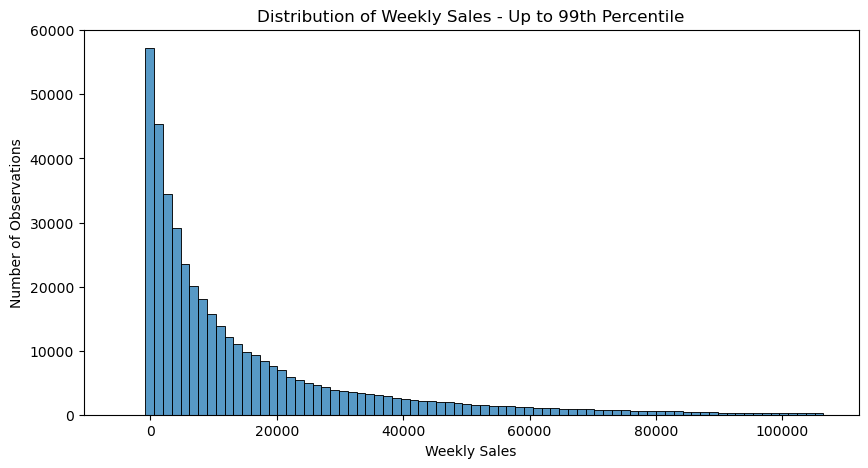

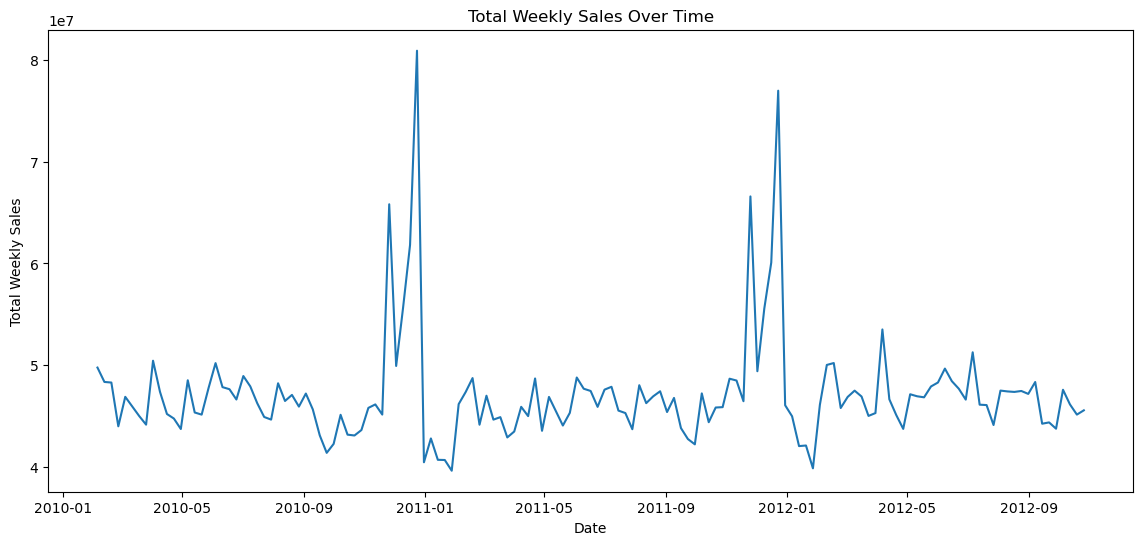

,mean,median,count
IsHoliday,,,
False,15901.445069,7589.95,391909
True,17035.823187,7947.74,29661


,mean,median,count
Type,,,
A,20099.568043,10105.17,215478
B,12237.075977,6187.87,163495
C,9519.532538,1149.67,42597


,Dept,Weekly_Sales
73,92,75204.870531
76,95,69824.423080
36,38,61090.619568
60,72,50566.515417
57,65,45441.706224
71,90,45232.084488
38,40,44900.702727
1,2,43607.020113
72,91,33687.910758
75,94,33405.883963


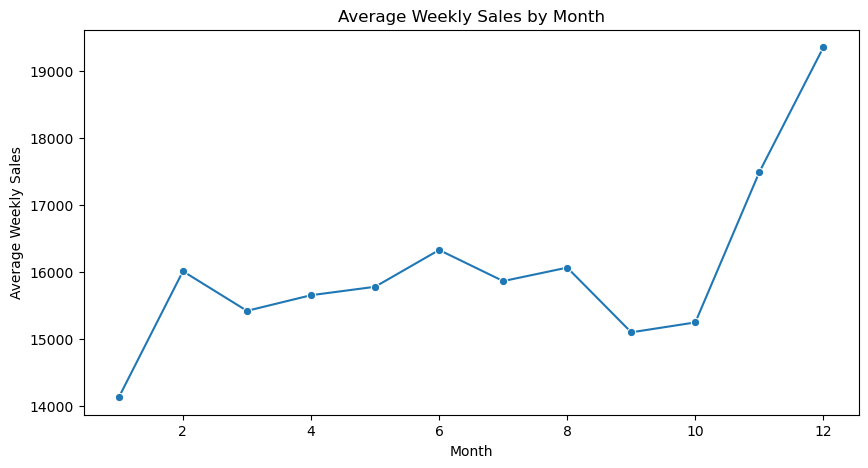

In [7]:
# ==================================================
# 4. EXPLORATORY DATA ANALYSIS
# ==================================================

import matplotlib.pyplot as plt
import seaborn as sns


# --------------------------------------------------
# 4.1 Target distribution
# --------------------------------------------------

sales_99 = train_merged["Weekly_Sales"].quantile(0.99)

print("99th percentile:", sales_99)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=train_merged[
        train_merged["Weekly_Sales"] <= sales_99
    ],
    x="Weekly_Sales",
    bins=80
)

plt.title("Distribution of Weekly Sales - Up to 99th Percentile")
plt.xlabel("Weekly Sales")
plt.ylabel("Number of Observations")

plt.show()


# --------------------------------------------------
# 4.2 Sales over time
# --------------------------------------------------

weekly_sales = (
    train_merged
    .groupby("Date", as_index=False)["Weekly_Sales"]
    .sum()
)

plt.figure(figsize=(14, 6))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Weekly_Sales"]
)

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")

plt.show()


# --------------------------------------------------
# 4.3 Holiday analysis
# --------------------------------------------------

holiday_sales = (
    train_merged
    .groupby("IsHoliday")["Weekly_Sales"]
    .agg(["mean", "median", "count"])
)

display(holiday_sales)


# --------------------------------------------------
# 4.4 Store type analysis
# --------------------------------------------------

store_type_sales = (
    train_merged
    .groupby("Type")["Weekly_Sales"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

display(store_type_sales)


# --------------------------------------------------
# 4.5 Department analysis
# --------------------------------------------------

department_sales = (
    train_merged
    .groupby("Dept", as_index=False)["Weekly_Sales"]
    .mean()
    .sort_values(
        "Weekly_Sales",
        ascending=False
    )
)

display(department_sales.head(10))


# --------------------------------------------------
# 4.6 Calendar features for EDA
# --------------------------------------------------

eda_data = train_merged.copy()

eda_data["Year"] = eda_data["Date"].dt.year
eda_data["Month"] = eda_data["Date"].dt.month

eda_data["WeekOfYear"] = (
    eda_data["Date"]
    .dt
    .isocalendar()
    .week
    .astype(int)
)


monthly_pattern = (
    eda_data
    .groupby("Month", as_index=False)["Weekly_Sales"]
    .mean()
)


plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_pattern,
    x="Month",
    y="Weekly_Sales",
    marker="o"
)

plt.title("Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")

plt.show()

Store Size / Sales Correlation


,Size,Weekly_Sales
Size,1.000000,0.846161
Weekly_Sales,0.846161,1.000000


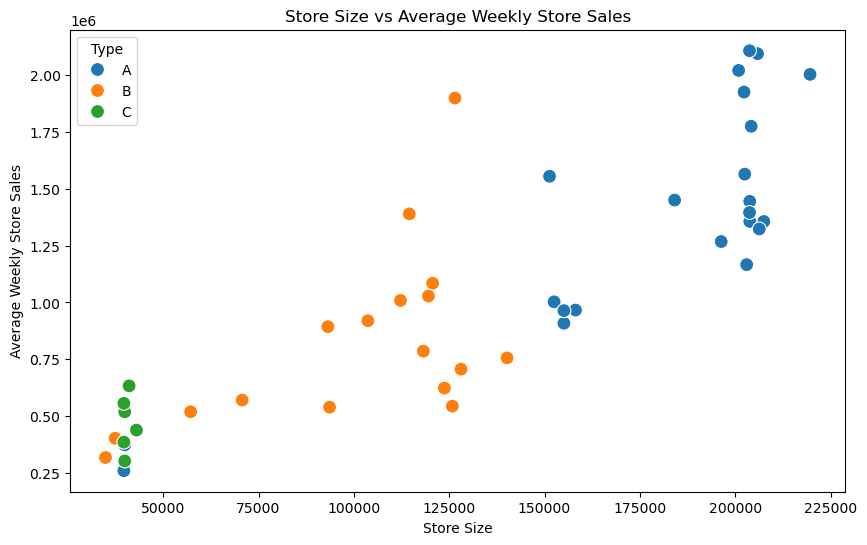

,Year,Weekly_Sales
0,2010,4.768513e+07
1,2011,4.708077e+07
2,2012,4.651472e+07


,Date,Weekly_Sales
6,2011-11-25,66593605.26
2,2010-11-26,65821003.24
8,2012-02-10,50009407.92
0,2010-02-12,48336677.63
9,2012-09-07,48330059.31
4,2011-02-11,47336192.79
5,2011-09-09,46763227.53
7,2011-12-30,46042461.04
1,2010-09-10,45634397.84
3,2010-12-31,40432519.00


In [8]:
# ==================================================
# 4.7 STORE SIZE ANALYSIS
# ==================================================

store_week_sales = (
    train_merged
    .groupby(
        ["Store", "Type", "Size", "Date"],
        as_index=False
    )["Weekly_Sales"]
    .sum()
)

store_avg_sales = (
    store_week_sales
    .groupby(
        ["Store", "Type", "Size"],
        as_index=False
    )["Weekly_Sales"]
    .mean()
)

print("Store Size / Sales Correlation")

display(
    store_avg_sales[
        ["Size", "Weekly_Sales"]
    ].corr()
)


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=store_avg_sales,
    x="Size",
    y="Weekly_Sales",
    hue="Type",
    s=100
)

plt.title("Store Size vs Average Weekly Store Sales")
plt.xlabel("Store Size")
plt.ylabel("Average Weekly Store Sales")

plt.show()



# ==================================================
# 4.8 YEAR-LEVEL ANALYSIS
# ==================================================

weekly_network_sales = (
    eda_data
    .groupby(
        ["Year", "Date"],
        as_index=False
    )["Weekly_Sales"]
    .sum()
)

yearly_avg_weekly_sales = (
    weekly_network_sales
    .groupby(
        "Year",
        as_index=False
    )["Weekly_Sales"]
    .mean()
)

display(yearly_avg_weekly_sales)



# ==================================================
# 4.9 INDIVIDUAL HOLIDAY WEEKS
# ==================================================

holiday_week_sales = (
    train_merged[
        train_merged["IsHoliday"]
    ]
    .groupby(
        "Date",
        as_index=False
    )["Weekly_Sales"]
    .sum()
    .sort_values(
        "Weekly_Sales",
        ascending=False
    )
)

display(holiday_week_sales)

In [9]:
# ==================================================
# 5. STATISTICAL & EXTERNAL FEATURE ANALYSIS
# ==================================================

external_features = [
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]


# --------------------------------------------------
# 5.1 Pearson Correlation
# --------------------------------------------------

pearson_corr = (
    train_merged[
        ["Weekly_Sales"] + external_features
    ]
    .corr(method="pearson")["Weekly_Sales"]
    .sort_values(ascending=False)
)

print("PEARSON CORRELATION")
display(pearson_corr)


# --------------------------------------------------
# 5.2 Spearman Correlation
# --------------------------------------------------

spearman_corr = (
    train_merged[
        ["Weekly_Sales"] + external_features
    ]
    .corr(method="spearman")["Weekly_Sales"]
    .sort_values(ascending=False)
)

print("SPEARMAN CORRELATION")
display(spearman_corr)


# --------------------------------------------------
# 5.3 Number of Valid Observations
# --------------------------------------------------

print("OBSERVATIONS USED")

for column in external_features:

    valid_rows = train_merged[
        ["Weekly_Sales", column]
    ].dropna()

    print(
        f"{column}: {len(valid_rows):,}"
    )


# --------------------------------------------------
# 5.4 Holiday Difference
# --------------------------------------------------

holiday = train_merged.loc[
    train_merged["IsHoliday"],
    "Weekly_Sales"
]

non_holiday = train_merged.loc[
    ~train_merged["IsHoliday"],
    "Weekly_Sales"
]

holiday_difference = (
    holiday.mean() -
    non_holiday.mean()
)

holiday_pct_difference = (
    holiday_difference /
    non_holiday.mean()
) * 100

print(
    "\nMean difference:",
    round(holiday_difference, 2)
)

print(
    "Percentage difference:",
    round(holiday_pct_difference, 2),
    "%"
)


# --------------------------------------------------
# 5.5 Welch's T-Test
# --------------------------------------------------

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    holiday,
    non_holiday,
    equal_var=False
)

print("\nWelch T-test")
print("T-statistic:", t_stat)
print("P-value:", p_value)

PEARSON CORRELATION


Weekly_Sales    1.000000
MarkDown5       0.090362
MarkDown1       0.085251
MarkDown3       0.060385
MarkDown4       0.045414
MarkDown2       0.024130
Fuel_Price     -0.000120
Temperature    -0.002312
CPI            -0.020921
Unemployment   -0.025864
Name: Weekly_Sales, dtype: float64

SPEARMAN CORRELATION


Weekly_Sales    1.000000
MarkDown5       0.207922
MarkDown1       0.192294
MarkDown3       0.135355
MarkDown4       0.112242
MarkDown2       0.031623
Fuel_Price      0.001993
Unemployment   -0.016481
Temperature    -0.019752
CPI            -0.023190
Name: Weekly_Sales, dtype: float64

OBSERVATIONS USED
Temperature: 421,570
Fuel_Price: 421,570
CPI: 421,570
Unemployment: 421,570
MarkDown1: 150,681
MarkDown2: 111,248
MarkDown3: 137,091
MarkDown4: 134,967
MarkDown5: 151,432

Mean difference: 1134.38
Percentage difference: 7.13 %

Welch T-test
T-statistic: 7.000740275222607
P-value: 2.5951250265739975e-12


In [10]:
# ==================================================
# 6. FEATURE ENGINEERING
# ==================================================

import numpy as np


train_features = train_merged.copy()
test_features = test_merged.copy()


# --------------------------------------------------
# Calendar features
# --------------------------------------------------

for df in [train_features, test_features]:

    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month

    df["WeekOfYear"] = (
        df["Date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    df["Quarter"] = df["Date"].dt.quarter


# --------------------------------------------------
# Markdown missing indicators
# --------------------------------------------------

markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]


for df in [train_features, test_features]:

    for col in markdown_cols:

        df[f"{col}_Missing"] = (
            df[col]
            .isna()
            .astype(int)
        )

    df[markdown_cols] = (
        df[markdown_cols]
        .fillna(0)
    )


# --------------------------------------------------
# Historical sales feature
# --------------------------------------------------

train_features = train_features.sort_values(
    ["Store", "Dept", "Date"]
)

train_features["Lag_52"] = (
    train_features
    .groupby(
        ["Store", "Dept"]
    )["Weekly_Sales"]
    .shift(52)
)


# --------------------------------------------------
# Validation split
# --------------------------------------------------

validation_start = pd.Timestamp(
    "2012-08-03"
)

model_train = train_features[
    train_features["Date"] < validation_start
].copy()

validation = train_features[
    train_features["Date"] >= validation_start
].copy()


print(
    "Training period:",
    model_train["Date"].min(),
    "to",
    model_train["Date"].max()
)

print(
    "Validation period:",
    validation["Date"].min(),
    "to",
    validation["Date"].max()
)


# --------------------------------------------------
# Seasonal naive baseline
# --------------------------------------------------

validation_baseline = validation.dropna(
    subset=["Lag_52"]
).copy()

validation_baseline["Prediction"] = (
    validation_baseline["Lag_52"]
)


# --------------------------------------------------
# MAE
# --------------------------------------------------

from sklearn.metrics import mean_absolute_error


baseline_mae = mean_absolute_error(
    validation_baseline["Weekly_Sales"],
    validation_baseline["Prediction"]
)


# --------------------------------------------------
# WMAE
# --------------------------------------------------

def weighted_mae(
    actual,
    predicted,
    is_holiday
):

    weights = np.where(
        is_holiday,
        5,
        1
    )

    errors = np.abs(
        actual - predicted
    )

    return np.sum(
        weights * errors
    ) / np.sum(weights)


baseline_wmae = weighted_mae(
    validation_baseline["Weekly_Sales"],
    validation_baseline["Prediction"],
    validation_baseline["IsHoliday"]
)


print(
    "\nSeasonal Baseline MAE:",
    round(baseline_mae, 2)
)

print(
    "Seasonal Baseline WMAE:",
    round(baseline_wmae, 2)
)

print(
    "Validation observations:",
    len(validation_baseline)
)

Training period: 2010-02-05 00:00:00 to 2012-07-27 00:00:00
Validation period: 2012-08-03 00:00:00 to 2012-10-26 00:00:00

Seasonal Baseline MAE: 1754.75
Seasonal Baseline WMAE: 1776.11
Validation observations: 37865


In [11]:
# ==================================================
# 6.1 ROBUST SEASONAL BASELINE
# ==================================================

# -----------------------------------------------
# Historical lookup from TRAINING data only
# -----------------------------------------------

history_lookup = model_train[
    [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales"
    ]
].copy()


# Move historical dates forward by exactly 52 weeks
history_lookup["Date"] = (
    history_lookup["Date"]
    + pd.Timedelta(weeks=52)
)


# Rename historical target
history_lookup = history_lookup.rename(
    columns={
        "Weekly_Sales": "Lag_364d"
    }
)


# -----------------------------------------------
# Attach exact seasonal history to validation
# -----------------------------------------------

validation_exact = validation.merge(
    history_lookup,
    on=["Store", "Dept", "Date"],
    how="left",
    validate="one_to_one"
)


# -----------------------------------------------
# Store-Department fallback
# Calculated ONLY from model training data
# -----------------------------------------------

store_dept_median = (
    model_train
    .groupby(
        ["Store", "Dept"]
    )["Weekly_Sales"]
    .median()
    .rename("StoreDeptMedian")
    .reset_index()
)


validation_exact = validation_exact.merge(
    store_dept_median,
    on=["Store", "Dept"],
    how="left",
    validate="many_to_one"
)


# -----------------------------------------------
# Global fallback
# -----------------------------------------------

global_median = (
    model_train["Weekly_Sales"]
    .median()
)


# -----------------------------------------------
# Final baseline prediction
# -----------------------------------------------

validation_exact["Prediction"] = (
    validation_exact["Lag_364d"]
    .fillna(
        validation_exact["StoreDeptMedian"]
    )
    .fillna(global_median)
)


# -----------------------------------------------
# Identify prediction source
# -----------------------------------------------

validation_exact["PredictionSource"] = (
    np.select(
        [
            validation_exact[
                "Lag_364d"
            ].notna(),

            validation_exact[
                "StoreDeptMedian"
            ].notna()
        ],
        [
            "Exact_52_Week_Lag",
            "StoreDept_Median"
        ],
        default="Global_Median"
    )
)


print("PREDICTION SOURCES")

print(
    validation_exact[
        "PredictionSource"
    ].value_counts()
)


# -----------------------------------------------
# Evaluation
# -----------------------------------------------

improved_baseline_mae = mean_absolute_error(
    validation_exact["Weekly_Sales"],
    validation_exact["Prediction"]
)


improved_baseline_wmae = weighted_mae(
    validation_exact["Weekly_Sales"],
    validation_exact["Prediction"],
    validation_exact["IsHoliday"]
)


print(
    "\nImproved Seasonal Baseline MAE:",
    round(improved_baseline_mae, 2)
)

print(
    "Improved Seasonal Baseline WMAE:",
    round(improved_baseline_wmae, 2)
)

print(
    "Rows evaluated:",
    len(validation_exact)
)

PREDICTION SOURCES
PredictionSource
Exact_52_Week_Lag    37590
StoreDept_Median       918
Global_Median           22
Name: count, dtype: int64

Improved Seasonal Baseline MAE: 1680.82
Improved Seasonal Baseline WMAE: 1706.99
Rows evaluated: 38530


In [12]:
# ==================================================
# 7. FIRST MACHINE LEARNING MODEL - RIDGE
# ==================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error


# --------------------------------------------------
# 7.1 Exact 52-week lag
# --------------------------------------------------

lag_lookup = train_features[
    ["Store", "Dept", "Date", "Weekly_Sales"]
].copy()

lag_lookup["Date"] = (
    lag_lookup["Date"]
    + pd.Timedelta(weeks=52)
)

lag_lookup = lag_lookup.rename(
    columns={
        "Weekly_Sales": "Lag_364d"
    }
)

ml_data = train_features.drop(
    columns=["Lag_52"],
    errors="ignore"
).merge(
    lag_lookup,
    on=["Store", "Dept", "Date"],
    how="left",
    validate="one_to_one"
)


# --------------------------------------------------
# 7.2 Holiday Type
# --------------------------------------------------

conditions = [
    ml_data["IsHoliday"]
    & (ml_data["Date"].dt.month == 2),

    ml_data["IsHoliday"]
    & (ml_data["Date"].dt.month == 9),

    ml_data["IsHoliday"]
    & (ml_data["Date"].dt.month == 11),

    ml_data["IsHoliday"]
    & (ml_data["Date"].dt.month == 12)
]

choices = [
    "SuperBowl",
    "LaborDay",
    "Thanksgiving",
    "Christmas"
]

ml_data["HolidayType"] = np.select(
    conditions,
    choices,
    default="None"
)


# --------------------------------------------------
# 7.3 Time-based split
# --------------------------------------------------

validation_start = pd.Timestamp("2012-08-03")

ml_train = ml_data[
    ml_data["Date"] < validation_start
].copy()

ml_validation = ml_data[
    ml_data["Date"] >= validation_start
].copy()


# --------------------------------------------------
# 7.4 Historical fallback values
# --------------------------------------------------

store_dept_medians = (
    ml_train
    .groupby(
        ["Store", "Dept"]
    )["Weekly_Sales"]
    .median()
)

global_median = (
    ml_train["Weekly_Sales"]
    .median()
)


def fill_lag_fallback(
    df,
    medians,
    global_value
):

    df = df.copy()

    fallback = pd.MultiIndex.from_frame(
        df[["Store", "Dept"]]
    ).map(medians)

    fallback = pd.Series(
        fallback,
        index=df.index,
        dtype="float64"
    )

    df["Lag_364d"] = (
        df["Lag_364d"]
        .fillna(fallback)
        .fillna(global_value)
    )

    return df


ml_train = fill_lag_fallback(
    ml_train,
    store_dept_medians,
    global_median
)

ml_validation = fill_lag_fallback(
    ml_validation,
    store_dept_medians,
    global_median
)


# --------------------------------------------------
# 7.5 Cyclical calendar features
# --------------------------------------------------

for df in [ml_train, ml_validation]:

    df["Month_sin"] = np.sin(
        2 * np.pi * df["Month"] / 12
    )

    df["Month_cos"] = np.cos(
        2 * np.pi * df["Month"] / 12
    )

    df["Week_sin"] = np.sin(
        2 * np.pi
        * df["WeekOfYear"]
        / 52
    )

    df["Week_cos"] = np.cos(
        2 * np.pi
        * df["WeekOfYear"]
        / 52
    )


# --------------------------------------------------
# 7.6 Feature groups
# --------------------------------------------------

categorical_features = [
    "Store",
    "Dept",
    "Type",
    "HolidayType"
]

binary_features = [
    "IsHoliday",
    "MarkDown1_Missing",
    "MarkDown2_Missing",
    "MarkDown3_Missing",
    "MarkDown4_Missing",
    "MarkDown5_Missing"
]

numeric_features = [
    "Size",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "Lag_364d",
    "Month_sin",
    "Month_cos",
    "Week_sin",
    "Week_cos"
]

feature_columns = (
    categorical_features
    + binary_features
    + numeric_features
)


# --------------------------------------------------
# 7.7 X and y
# --------------------------------------------------

X_train = ml_train[
    feature_columns
]

y_train = ml_train[
    "Weekly_Sales"
]

X_val = ml_validation[
    feature_columns
]

y_val = ml_validation[
    "Weekly_Sales"
]


# --------------------------------------------------
# 7.8 Preprocessing
# --------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)


# --------------------------------------------------
# 7.9 Ridge model
# --------------------------------------------------

ridge_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            Ridge(alpha=1.0)
        )
    ]
)


# Train
ridge_model.fit(
    X_train,
    y_train
)


# Predict
ridge_predictions = (
    ridge_model.predict(
        X_val
    )
)


# --------------------------------------------------
# 7.10 Evaluation
# --------------------------------------------------

ridge_mae = mean_absolute_error(
    y_val,
    ridge_predictions
)

ridge_wmae = weighted_mae(
    y_val,
    ridge_predictions,
    ml_validation["IsHoliday"]
)


print(
    "Ridge MAE:",
    round(ridge_mae, 2)
)

print(
    "Ridge WMAE:",
    round(ridge_wmae, 2)
)

print(
    "\nSeasonal Baseline WMAE:",
    round(
        improved_baseline_wmae,
        2
    )
)


ridge_improvement = (
    (
        improved_baseline_wmae
        - ridge_wmae
    )
    /
    improved_baseline_wmae
) * 100


print(
    "WMAE improvement vs baseline:",
    round(
        ridge_improvement,
        2
    ),
    "%"
)

Ridge MAE: 1874.99
Ridge WMAE: 1878.24

Seasonal Baseline WMAE: 1706.99
WMAE improvement vs baseline: -10.03 %


OVERALL RESIDUAL ANALYSIS

SEASONAL BASELINE RESIDUALS
count    38530.000000
mean       226.734719
std       3603.670797
min     -96110.280000
25%       -501.505000
50%         33.005000
75%        901.020000
max      87168.200000
Name: BaselineError, dtype: float64

RIDGE RESIDUALS
count    38530.000000
mean      -224.969602
std       3591.803618
min     -91015.863557
25%      -1229.367190
50%       -157.515233
75%        772.978144
max      85467.613136
Name: RidgeError, dtype: float64

HOLIDAY VS NON-HOLIDAY PERFORMANCE


,Rows,Actual_Mean,Baseline_MAE,Ridge_MAE
IsHoliday,,,,
False,35564,15564.276551,1671.543228,1873.832609
True,2966,16294.692957,1791.990312,1888.817592



PERFORMANCE BY STORE TYPE


,Rows,Actual_Mean,Baseline_MAE,Ridge_MAE
Type,,,,
A,19640,19724.739411,2020.450797,2161.771039
B,14887,11866.429406,1461.680741,1673.535652
C,4003,9445.059695,829.405892,1217.114015



PERFORMANCE BY SALES BAND


,Rows,Actual_Mean,Baseline_MAE,Ridge_MAE
SalesBand,,,,
Bottom 50%,19265,2484.270180,515.177409,910.024345
50-90%,15412,18730.042425,2051.686734,2108.316058
90-99%,3467,61740.327730,5529.222680,5273.184274
Top 1%,386,132842.993420,10483.168083,10197.149997



TOP 10 DEPARTMENTS WHERE RIDGE IS WORSE


,Rows,Actual_Mean,Baseline_MAE,Ridge_MAE,RidgeMinusBaseline
Dept,,,,,
65,13,50291.269231,14493.013077,15954.166514,1461.153437
18,484,5371.802231,1420.680083,2851.468870,1430.788787
72,549,44411.462259,7372.596339,8091.648609,719.052270
5,585,16891.150650,3196.099795,3872.243586,676.143791
1,585,17583.666274,1502.861607,2118.721450,615.859843
54,366,34.044836,44.086448,625.719183,581.632735
45,75,23.109600,14.103267,592.700055,578.596789
55,497,7123.145292,1421.855070,1956.500234,534.645164
59,512,204.911250,98.796270,616.088761,517.292491



TOP 10 DEPARTMENTS WHERE RIDGE IS BETTER


,Rows,Actual_Mean,Baseline_MAE,Ridge_MAE,RidgeMinusBaseline
Dept,,,,,
92,585,79403.508547,6780.783402,6162.726820,-618.056581
87,584,15823.558579,2556.743904,2333.181010,-223.562894
95,585,71468.548940,4735.928325,4548.404284,-187.524041
40,585,45783.600667,3234.300632,3089.193060,-145.107572
38,585,59533.667128,7872.112291,7761.584704,-110.527587
82,585,15392.258359,1688.559197,1584.852769,-103.706428
4,585,26593.157795,1684.562838,1601.002160,-83.560678
8,585,30759.386530,2148.548940,2088.472058,-60.076882
79,585,21526.012342,2021.656274,1964.801355,-56.854918


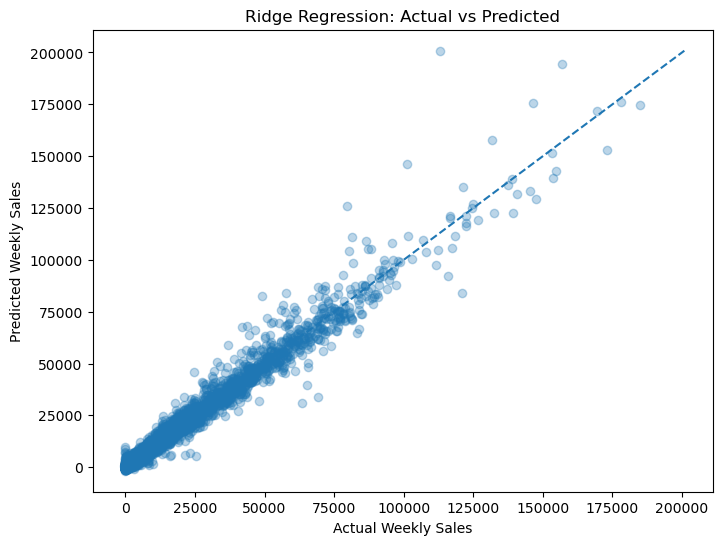

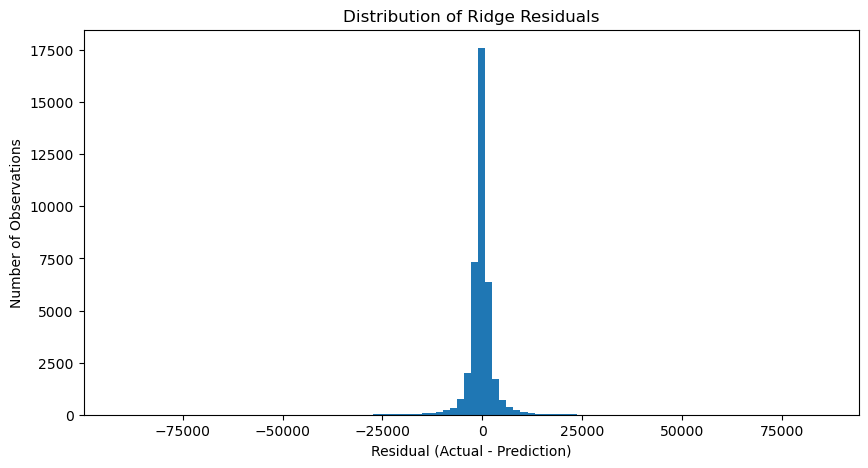


FINAL MODEL COMPARISON
Seasonal Baseline MAE: 1680.82
Seasonal Baseline WMAE: 1706.99

Ridge MAE: 1874.99
Ridge WMAE: 1878.24

Ridge WMAE difference vs baseline: 10.03 %


In [13]:
# ==================================================
# 8. MODEL DIAGNOSTICS
# Compare Ridge Regression vs Seasonal Baseline
# ==================================================

import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------
# 8.1 Build Ridge evaluation dataframe
# --------------------------------------------------

ridge_eval = ml_validation[
    [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales",
        "IsHoliday",
        "Type"
    ]
].copy()

ridge_eval["RidgePrediction"] = ridge_predictions


# --------------------------------------------------
# 8.2 Prepare Seasonal Baseline predictions
# --------------------------------------------------

baseline_eval = validation_exact[
    [
        "Store",
        "Dept",
        "Date",
        "Prediction"
    ]
].copy()

baseline_eval = baseline_eval.rename(
    columns={
        "Prediction": "BaselinePrediction"
    }
)


# --------------------------------------------------
# 8.3 Merge both model predictions
# --------------------------------------------------

comparison = ridge_eval.merge(
    baseline_eval,
    on=["Store", "Dept", "Date"],
    how="left",
    validate="one_to_one"
)


# --------------------------------------------------
# 8.4 Calculate residuals
# Residual = Actual - Predicted
# Positive  -> underprediction
# Negative  -> overprediction
# --------------------------------------------------

comparison["BaselineError"] = (
    comparison["Weekly_Sales"]
    - comparison["BaselinePrediction"]
)

comparison["RidgeError"] = (
    comparison["Weekly_Sales"]
    - comparison["RidgePrediction"]
)


# Absolute errors
comparison["BaselineAbsError"] = (
    comparison["BaselineError"].abs()
)

comparison["RidgeAbsError"] = (
    comparison["RidgeError"].abs()
)


# --------------------------------------------------
# 8.5 Overall residual statistics
# --------------------------------------------------

print("=" * 60)
print("OVERALL RESIDUAL ANALYSIS")
print("=" * 60)

print("\nSEASONAL BASELINE RESIDUALS")
print(
    comparison["BaselineError"].describe()
)

print("\nRIDGE RESIDUALS")
print(
    comparison["RidgeError"].describe()
)


# --------------------------------------------------
# 8.6 Holiday vs Non-Holiday performance
# --------------------------------------------------

holiday_model_comparison = (
    comparison
    .groupby("IsHoliday")
    .agg(
        Rows=(
            "Weekly_Sales",
            "size"
        ),
        Actual_Mean=(
            "Weekly_Sales",
            "mean"
        ),
        Baseline_MAE=(
            "BaselineAbsError",
            "mean"
        ),
        Ridge_MAE=(
            "RidgeAbsError",
            "mean"
        )
    )
)

print("\n" + "=" * 60)
print("HOLIDAY VS NON-HOLIDAY PERFORMANCE")
print("=" * 60)

display(
    holiday_model_comparison
)


# --------------------------------------------------
# 8.7 Store Type performance
# --------------------------------------------------

type_model_comparison = (
    comparison
    .groupby("Type")
    .agg(
        Rows=(
            "Weekly_Sales",
            "size"
        ),
        Actual_Mean=(
            "Weekly_Sales",
            "mean"
        ),
        Baseline_MAE=(
            "BaselineAbsError",
            "mean"
        ),
        Ridge_MAE=(
            "RidgeAbsError",
            "mean"
        )
    )
)

print("\n" + "=" * 60)
print("PERFORMANCE BY STORE TYPE")
print("=" * 60)

display(
    type_model_comparison
)


# --------------------------------------------------
# 8.8 Performance by Sales Band
# --------------------------------------------------
# Creates groups based on actual validation sales:
# Bottom 50%
# 50-90%
# 90-99%
# Top 1%

comparison["SalesBand"] = pd.qcut(
    comparison["Weekly_Sales"],
    q=[
        0,
        0.50,
        0.90,
        0.99,
        1.0
    ],
    labels=[
        "Bottom 50%",
        "50-90%",
        "90-99%",
        "Top 1%"
    ]
)


sales_band_comparison = (
    comparison
    .groupby(
        "SalesBand",
        observed=True
    )
    .agg(
        Rows=(
            "Weekly_Sales",
            "size"
        ),
        Actual_Mean=(
            "Weekly_Sales",
            "mean"
        ),
        Baseline_MAE=(
            "BaselineAbsError",
            "mean"
        ),
        Ridge_MAE=(
            "RidgeAbsError",
            "mean"
        )
    )
)

print("\n" + "=" * 60)
print("PERFORMANCE BY SALES BAND")
print("=" * 60)

display(
    sales_band_comparison
)


# --------------------------------------------------
# 8.9 Department-level error comparison
# --------------------------------------------------

department_errors = (
    comparison
    .groupby("Dept")
    .agg(
        Rows=(
            "Weekly_Sales",
            "size"
        ),
        Actual_Mean=(
            "Weekly_Sales",
            "mean"
        ),
        Baseline_MAE=(
            "BaselineAbsError",
            "mean"
        ),
        Ridge_MAE=(
            "RidgeAbsError",
            "mean"
        )
    )
)


department_errors[
    "RidgeMinusBaseline"
] = (
    department_errors["Ridge_MAE"]
    - department_errors["Baseline_MAE"]
)


print("\n" + "=" * 60)
print("TOP 10 DEPARTMENTS WHERE RIDGE IS WORSE")
print("=" * 60)

display(
    department_errors
    .sort_values(
        "RidgeMinusBaseline",
        ascending=False
    )
    .head(10)
)


print("\n" + "=" * 60)
print("TOP 10 DEPARTMENTS WHERE RIDGE IS BETTER")
print("=" * 60)

display(
    department_errors
    .sort_values(
        "RidgeMinusBaseline",
        ascending=True
    )
    .head(10)
)


# --------------------------------------------------
# 8.10 Actual vs Predicted scatter plot
# --------------------------------------------------

prediction_sample = comparison.sample(
    n=min(
        5000,
        len(comparison)
    ),
    random_state=42
)


plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    prediction_sample["Weekly_Sales"],
    prediction_sample["RidgePrediction"],
    alpha=0.3
)


min_value = min(
    prediction_sample[
        "Weekly_Sales"
    ].min(),
    prediction_sample[
        "RidgePrediction"
    ].min()
)

max_value = max(
    prediction_sample[
        "Weekly_Sales"
    ].max(),
    prediction_sample[
        "RidgePrediction"
    ].max()
)


# Perfect-prediction reference line
plt.plot(
    [
        min_value,
        max_value
    ],
    [
        min_value,
        max_value
    ],
    linestyle="--"
)

plt.xlabel(
    "Actual Weekly Sales"
)

plt.ylabel(
    "Predicted Weekly Sales"
)

plt.title(
    "Ridge Regression: Actual vs Predicted"
)

plt.show()


# --------------------------------------------------
# 8.11 Residual distribution
# --------------------------------------------------

plt.figure(
    figsize=(10, 5)
)

plt.hist(
    comparison["RidgeError"],
    bins=100
)

plt.xlabel(
    "Residual (Actual - Prediction)"
)

plt.ylabel(
    "Number of Observations"
)

plt.title(
    "Distribution of Ridge Residuals"
)

plt.show()


# --------------------------------------------------
# 8.12 Summary comparison
# --------------------------------------------------

print("\n" + "=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

print(
    "Seasonal Baseline MAE:",
    round(
        improved_baseline_mae,
        2
    )
)

print(
    "Seasonal Baseline WMAE:",
    round(
        improved_baseline_wmae,
        2
    )
)

print(
    "\nRidge MAE:",
    round(
        ridge_mae,
        2
    )
)

print(
    "Ridge WMAE:",
    round(
        ridge_wmae,
        2
    )
)

ridge_difference = (
    (
        ridge_wmae
        - improved_baseline_wmae
    )
    /
    improved_baseline_wmae
) * 100

print(
    "\nRidge WMAE difference vs baseline:",
    round(
        ridge_difference,
        2
    ),
    "%"
)

In [14]:
# ==================================================
# 9. DECISION TREE REGRESSION
# ==================================================

import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error


# --------------------------------------------------
# 9.1 Preprocessing
# --------------------------------------------------
# Trees DO NOT require StandardScaler.
#
# Numerical columns:
# - fill missing values using training median
#
# Categorical columns:
# - convert categories using one-hot encoding
#
# Binary columns:
# - pass through unchanged
# --------------------------------------------------

tree_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


tree_categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            tree_numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            tree_categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)


# --------------------------------------------------
# 9.2 Decision Tree model
# --------------------------------------------------

decision_tree = DecisionTreeRegressor(
    max_depth=15,
    min_samples_leaf=20,
    random_state=42
)


tree_model = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "model",
            decision_tree
        )
    ]
)


# --------------------------------------------------
# 9.3 Holiday sample weights
# --------------------------------------------------
# Walmart WMAE gives:
#
# Holiday     -> weight 5
# Normal week -> weight 1
#
# We therefore give holiday observations more
# importance during model training as well.
# --------------------------------------------------

train_weights = np.where(
    ml_train["IsHoliday"],
    5,
    1
)


# --------------------------------------------------
# 9.4 Train model
# --------------------------------------------------

tree_model.fit(
    X_train,
    y_train,
    model__sample_weight=train_weights
)


# --------------------------------------------------
# 9.5 Prediction
# --------------------------------------------------

tree_predictions = tree_model.predict(
    X_val
)


# --------------------------------------------------
# 9.6 Evaluation
# --------------------------------------------------

tree_mae = mean_absolute_error(
    y_val,
    tree_predictions
)


tree_wmae = weighted_mae(
    y_val,
    tree_predictions,
    ml_validation["IsHoliday"]
)


# --------------------------------------------------
# 9.7 Compare with previous models
# --------------------------------------------------

tree_improvement = (
    (
        improved_baseline_wmae
        - tree_wmae
    )
    /
    improved_baseline_wmae
) * 100


print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(
    "Seasonal Baseline MAE:",
    round(improved_baseline_mae, 2)
)

print(
    "Seasonal Baseline WMAE:",
    round(improved_baseline_wmae, 2)
)

print()

print(
    "Ridge MAE:",
    round(ridge_mae, 2)
)

print(
    "Ridge WMAE:",
    round(ridge_wmae, 2)
)

print()

print(
    "Decision Tree MAE:",
    round(tree_mae, 2)
)

print(
    "Decision Tree WMAE:",
    round(tree_wmae, 2)
)

print()

print(
    "Decision Tree WMAE improvement vs baseline:",
    round(tree_improvement, 2),
    "%"
)

MODEL COMPARISON
Seasonal Baseline MAE: 1680.82
Seasonal Baseline WMAE: 1706.99

Ridge MAE: 1874.99
Ridge WMAE: 1878.24

Decision Tree MAE: 1761.36
Decision Tree WMAE: 1780.85

Decision Tree WMAE improvement vs baseline: -4.33 %


In [15]:
# ==================================================
# 10. CLEAN ML DATASET - REMOVE LAG FALLBACK LEAKAGE
# ==================================================

import numpy as np
import pandas as pd


# --------------------------------------------------
# 10.1 Create exact 52-week historical sales lookup
# --------------------------------------------------

lag_lookup = train_features[
    [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales"
    ]
].copy()

lag_lookup["Date"] = (
    lag_lookup["Date"]
    + pd.Timedelta(weeks=52)
)

lag_lookup = lag_lookup.rename(
    columns={
        "Weekly_Sales": "Lag_364d"
    }
)


# --------------------------------------------------
# 10.2 Build clean ML dataset
# --------------------------------------------------

ml_data_clean = (
    train_features
    .drop(
        columns=["Lag_52"],
        errors="ignore"
    )
    .merge(
        lag_lookup,
        on=["Store", "Dept", "Date"],
        how="left",
        validate="one_to_one"
    )
)


# --------------------------------------------------
# 10.3 Create lag missing indicator
# --------------------------------------------------

ml_data_clean[
    "Lag_364d_Missing"
] = (
    ml_data_clean["Lag_364d"]
    .isna()
    .astype(int)
)


# --------------------------------------------------
# 10.4 Holiday Type
# --------------------------------------------------

conditions = [
    ml_data_clean["IsHoliday"]
    & (ml_data_clean["Date"].dt.month == 2),

    ml_data_clean["IsHoliday"]
    & (ml_data_clean["Date"].dt.month == 9),

    ml_data_clean["IsHoliday"]
    & (ml_data_clean["Date"].dt.month == 11),

    ml_data_clean["IsHoliday"]
    & (ml_data_clean["Date"].dt.month == 12)
]

choices = [
    "SuperBowl",
    "LaborDay",
    "Thanksgiving",
    "Christmas"
]

ml_data_clean["HolidayType"] = (
    np.select(
        conditions,
        choices,
        default="None"
    )
)


# --------------------------------------------------
# 10.5 Time-based split
# --------------------------------------------------

validation_start = pd.Timestamp(
    "2012-08-03"
)

ml_train_clean = ml_data_clean[
    ml_data_clean["Date"]
    < validation_start
].copy()

ml_validation_clean = ml_data_clean[
    ml_data_clean["Date"]
    >= validation_start
].copy()


# --------------------------------------------------
# 10.6 Cyclical calendar features
# --------------------------------------------------

for df in [
    ml_train_clean,
    ml_validation_clean
]:

    df["Month_sin"] = np.sin(
        2 * np.pi
        * df["Month"] / 12
    )

    df["Month_cos"] = np.cos(
        2 * np.pi
        * df["Month"] / 12
    )

    df["Week_sin"] = np.sin(
        2 * np.pi
        * df["WeekOfYear"] / 52
    )

    df["Week_cos"] = np.cos(
        2 * np.pi
        * df["WeekOfYear"] / 52
    )


print(
    "Training rows:",
    len(ml_train_clean)
)

print(
    "Validation rows:",
    len(ml_validation_clean)
)

print(
    "\nMissing Lag_364d - Training:",
    ml_train_clean[
        "Lag_364d"
    ].isna().sum()
)

print(
    "Missing Lag_364d - Validation:",
    ml_validation_clean[
        "Lag_364d"
    ].isna().sum()
)

Training rows: 383040
Validation rows: 38530

Missing Lag_364d - Training: 159089
Missing Lag_364d - Validation: 940


In [16]:
# ============================================================
# 11. RANDOM FOREST REGRESSION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


# ============================================================
# 11.1 Use only training observations with TRUE 52-week lag
# ============================================================

rf_train = ml_train_clean[
    ml_train_clean["Lag_364d"].notna()
].copy()


rf_validation = ml_validation_clean[
    ml_validation_clean["Lag_364d"].notna()
].copy()


print("Random Forest training rows:", len(rf_train))

print(
    "Validation rows with exact lag:",
    len(rf_validation)
)

print(
    "Validation rows requiring fallback:",
    ml_validation_clean["Lag_364d"].isna().sum()
)


# ============================================================
# 11.2 Feature groups
# ============================================================

# Store and Department are identifiers/categories,
# not continuous numerical measurements.

rf_categorical_features = [
    "Store",
    "Dept",
    "Type",
    "HolidayType"
]


# Binary features
rf_binary_features = [
    "IsHoliday",
    "MarkDown1_Missing",
    "MarkDown2_Missing",
    "MarkDown3_Missing",
    "MarkDown4_Missing",
    "MarkDown5_Missing"
]


# Numerical features
#
# For trees, raw Month / WeekOfYear / Quarter can be useful.
# StandardScaler is NOT necessary.

rf_numeric_features = [
    "Size",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",

    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",

    "Lag_364d",

    "Month",
    "WeekOfYear",
    "Quarter"
]


rf_feature_columns = (
    rf_categorical_features
    + rf_binary_features
    + rf_numeric_features
)


# ============================================================
# 11.3 Create X and y
# ============================================================

X_rf_train = rf_train[
    rf_feature_columns
]

y_rf_train = rf_train[
    "Weekly_Sales"
]


X_rf_val = rf_validation[
    rf_feature_columns
]

y_rf_val = rf_validation[
    "Weekly_Sales"
]


# ============================================================
# 11.4 Numerical preprocessing
# ============================================================
#
# We still keep an imputer because numerical features such
# as CPI / Unemployment may eventually contain missing values
# when we apply the model to future test data.
#
# No StandardScaler is required for Random Forest.
# ============================================================

rf_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


# ============================================================
# 11.5 Categorical preprocessing
# ============================================================

rf_categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ============================================================
# 11.6 Combine preprocessing
# ============================================================

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            rf_numeric_pipeline,
            rf_numeric_features
        ),

        (
            "cat",
            rf_categorical_pipeline,
            rf_categorical_features
        ),

        (
            "binary",
            "passthrough",
            rf_binary_features
        )
    ]
)


# ============================================================
# 11.7 Random Forest model
# ============================================================
#
# These are starting values — NOT tuned hyperparameters.
#
# n_estimators:
#   Number of individual decision trees.
#
# max_depth:
#   Limits how deep each tree can become.
#
# min_samples_leaf:
#   Prevents leaves based on tiny numbers of observations.
#
# max_features:
#   Each tree/split sees only part of the available feature set,
#   which increases diversity between trees.
#
# bootstrap=True:
#   Each tree is trained on a random resampled version of
#   the training data.
# ============================================================

random_forest = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    max_features=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)


rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            rf_preprocessor
        ),
        (
            "model",
            random_forest
        )
    ]
)


# ============================================================
# 11.8 Holiday sample weights
# ============================================================

rf_train_weights = np.where(
    rf_train["IsHoliday"],
    5,
    1
)


# ============================================================
# 11.9 Train Random Forest
# ============================================================

rf_model.fit(
    X_rf_train,
    y_rf_train,
    model__sample_weight=rf_train_weights
)


# ============================================================
# 11.10 Predict exact-lag validation rows
# ============================================================

rf_predictions = rf_model.predict(
    X_rf_val
)


# ============================================================
# 11.11 Direct Random Forest performance
# Only rows where exact Lag_364d exists
# ============================================================

rf_exact_mae = mean_absolute_error(
    y_rf_val,
    rf_predictions
)


rf_exact_wmae = weighted_mae(
    y_rf_val,
    rf_predictions,
    rf_validation["IsHoliday"]
)


print("\n" + "=" * 60)

print("RANDOM FOREST — EXACT-LAG ROWS")

print("=" * 60)

print(
    "MAE:",
    round(rf_exact_mae, 2)
)

print(
    "WMAE:",
    round(rf_exact_wmae, 2)
)


# ============================================================
# 11.12 Build prediction table
# ============================================================

rf_prediction_table = rf_validation[
    [
        "Store",
        "Dept",
        "Date"
    ]
].copy()


rf_prediction_table[
    "RF_Prediction"
] = rf_predictions


# ============================================================
# 11.13 Build complete validation evaluation
# ============================================================
#
# validation_exact already contains our robust seasonal
# baseline prediction for ALL 38,530 validation rows.
#
# We use:
#
# Random Forest -> when exact lag exists
# Baseline      -> when exact lag is unavailable
# ============================================================

rf_full_eval = validation_exact[
    [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales",
        "IsHoliday",
        "Prediction"
    ]
].copy()


rf_full_eval = rf_full_eval.rename(
    columns={
        "Prediction":
        "BaselinePrediction"
    }
)


rf_full_eval = rf_full_eval.merge(
    rf_prediction_table,
    on=[
        "Store",
        "Dept",
        "Date"
    ],
    how="left",
    validate="one_to_one"
)


# ============================================================
# 11.14 Hybrid prediction
# ============================================================

rf_full_eval[
    "FinalPrediction"
] = (
    rf_full_eval[
        "RF_Prediction"
    ]
    .fillna(
        rf_full_eval[
            "BaselinePrediction"
        ]
    )
)


# Track prediction source
rf_full_eval[
    "PredictionSource"
] = np.where(
    rf_full_eval[
        "RF_Prediction"
    ].notna(),

    "RandomForest",

    "SeasonalFallback"
)


# ============================================================
# 11.15 Evaluate ALL validation rows
# ============================================================

rf_full_mae = mean_absolute_error(
    rf_full_eval[
        "Weekly_Sales"
    ],

    rf_full_eval[
        "FinalPrediction"
    ]
)


rf_full_wmae = weighted_mae(
    rf_full_eval[
        "Weekly_Sales"
    ],

    rf_full_eval[
        "FinalPrediction"
    ],

    rf_full_eval[
        "IsHoliday"
    ]
)


# ============================================================
# 11.16 Improvement vs baseline
# ============================================================

rf_improvement = (
    (
        improved_baseline_wmae
        - rf_full_wmae
    )
    /
    improved_baseline_wmae
) * 100


# ============================================================
# 11.17 Prediction source counts
# ============================================================

print("\n" + "=" * 60)

print("PREDICTION SOURCES")

print("=" * 60)

print(
    rf_full_eval[
        "PredictionSource"
    ].value_counts()
)


# ============================================================
# 11.18 Final model comparison
# ============================================================

print("\n" + "=" * 60)

print("MODEL COMPARISON")

print("=" * 60)


print(
    "Seasonal Baseline MAE:",
    round(
        improved_baseline_mae,
        2
    )
)

print(
    "Seasonal Baseline WMAE:",
    round(
        improved_baseline_wmae,
        2
    )
)


print()


print(
    "Ridge MAE:",
    round(
        ridge_mae,
        2
    )
)

print(
    "Ridge WMAE:",
    round(
        ridge_wmae,
        2
    )
)


print()


print(
    "Decision Tree MAE:",
    round(
        tree_mae,
        2
    )
)

print(
    "Decision Tree WMAE:",
    round(
        tree_wmae,
        2
    )
)


print()


print(
    "Random Forest Hybrid MAE:",
    round(
        rf_full_mae,
        2
    )
)

print(
    "Random Forest Hybrid WMAE:",
    round(
        rf_full_wmae,
        2
    )
)


print()


print(
    "Random Forest improvement vs baseline:",
    round(
        rf_improvement,
        2
    ),
    "%"
)

Random Forest training rows: 223951
Validation rows with exact lag: 37590
Validation rows requiring fallback: 940

RANDOM FOREST — EXACT-LAG ROWS
MAE: 1593.51
WMAE: 1594.18

PREDICTION SOURCES
PredictionSource
RandomForest        37590
SeasonalFallback      940
Name: count, dtype: int64

MODEL COMPARISON
Seasonal Baseline MAE: 1680.82
Seasonal Baseline WMAE: 1706.99

Ridge MAE: 1874.99
Ridge WMAE: 1878.24

Decision Tree MAE: 1761.36
Decision Tree WMAE: 1780.85

Random Forest Hybrid MAE: 1566.37
Random Forest Hybrid WMAE: 1568.43

Random Forest improvement vs baseline: 8.12 %


TRAINING VS VALIDATION PERFORMANCE
Training MAE: 1335.56
Training WMAE: 1328.49

Validation Exact-Lag MAE: 1593.51
Validation Exact-Lag WMAE: 1594.18

EXACT-LAG ROWS: BASELINE VS RANDOM FOREST
Baseline Exact-Lag MAE: 1710.81
Baseline Exact-Lag WMAE: 1736.12

Random Forest Exact-Lag MAE: 1593.51
Random Forest Exact-Lag WMAE: 1594.18

FALLBACK ROW PERFORMANCE
Fallback rows: 940
Fallback MAE: 481.27
Fallback WMAE: 512.85

RANDOM FOREST RESIDUALS
count    37590.000000
mean      -217.765679
std       3263.389001
min     -67719.967161
25%       -860.761985
50%        -75.657156
75%        511.449320
max      85557.039465
Name: RFError, dtype: float64

Mean Residual:
-217.77
Median Residual:
-75.66

HOLIDAY VS NON-HOLIDAY


,Rows,Actual_Mean,Baseline_MAE,RandomForest_MAE,RF_Improvement
IsHoliday,,,,,
False,34689,15951.229232,1701.839837,1593.269086,108.570751
True,2901,16647.456942,1818.093078,1596.345834,221.747245



PERFORMANCE BY STORE TYPE


,Rows,Actual_Mean,Baseline_MAE,RandomForest_MAE,RF_Improvement
Type,,,,,
A,19305,20065.175341,2044.569288,1882.787187,161.782100
B,14566,12115.452327,1480.145676,1416.491031,63.654646
C,3719,10162.563826,881.741890,785.183002,96.558888



PERFORMANCE BY SALES BAND


,Rows,Actual_Mean,Baseline_MAE,RandomForest_MAE,RF_Improvement
SalesBand,,,,,
Bottom 50%,18795,2724.713566,530.883668,532.032021,-1.148353
50-90%,15036,19227.586806,2091.829743,2000.550000,91.279742
90-99%,3383,62385.369503,5591.103198,4935.960488,655.142711
Top 1%,376,133669.605612,10542.546383,8302.512298,2240.034085



TOP 10 DEPARTMENTS WHERE RF IS WORSE


,Rows,Actual_Mean,Baseline_MAE,RandomForest_MAE,RFMinusBaseline
Dept,,,,,
1,585,17583.666274,1502.861607,1856.976875,354.115268
90,585,46564.819385,3218.392701,3509.500943,291.108242
47,4,92.505000,164.255000,338.056883,173.801883
99,80,61.343250,223.695000,356.662877,132.967877
18,416,6240.157212,1321.640913,1434.994816,113.353902
16,585,8492.651248,1346.029573,1455.730319,109.700747
51,8,5.715000,16.890000,104.625548,87.735548
10,585,18534.915829,1735.349829,1820.978202,85.628373
11,585,12592.838188,1655.554376,1737.580919,82.026542



TOP 10 DEPARTMENTS WHERE RF IS BETTER


,Rows,Actual_Mean,Baseline_MAE,RandomForest_MAE,RFMinusBaseline
Dept,,,,,
92,585,79403.508547,6780.783402,5024.511406,-1756.271996
38,585,59533.667128,7872.112291,6608.630150,-1263.482141
87,581,15904.585559,2569.570275,1846.143912,-723.426363
72,544,44819.296471,7439.861857,6753.405240,-686.456617
95,585,71468.548940,4735.928325,4123.064911,-612.863413
40,585,45783.600667,3234.300632,2642.404679,-591.895953
93,530,28351.090170,3012.259226,2471.693646,-540.565581
94,497,34512.289014,2835.223481,2322.997933,-512.225548
8,585,30759.386530,2148.548940,1703.238778,-445.310162


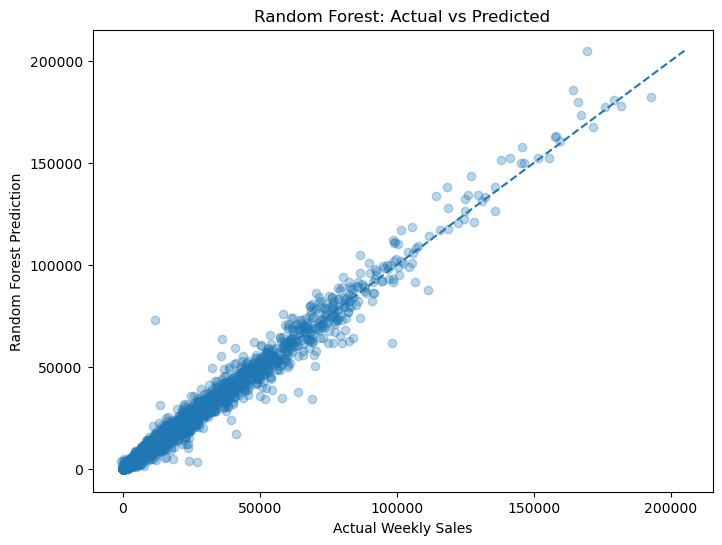

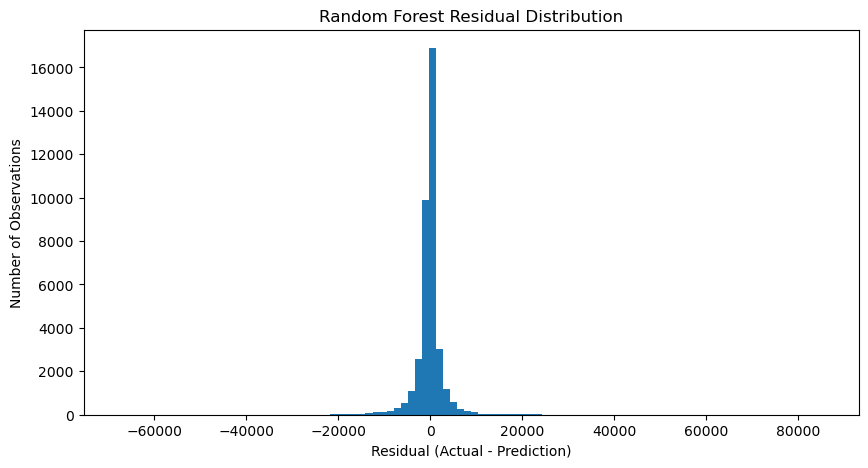

In [17]:
# ============================================================
# 12. RANDOM FOREST DIAGNOSTICS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error


# ============================================================
# 12.1 TRAINING PERFORMANCE
# ============================================================
#
# Predict the SAME rows used to train the Random Forest.
#
# IMPORTANT:
# Training performance will naturally look better than
# validation performance.
#
# We calculate it only to diagnose possible overfitting.
# ============================================================

rf_train_predictions = rf_model.predict(
    X_rf_train
)


rf_train_mae = mean_absolute_error(
    y_rf_train,
    rf_train_predictions
)


rf_train_wmae = weighted_mae(
    y_rf_train,
    rf_train_predictions,
    rf_train["IsHoliday"]
)


print("=" * 65)
print("TRAINING VS VALIDATION PERFORMANCE")
print("=" * 65)

print(
    "Training MAE:",
    round(rf_train_mae, 2)
)

print(
    "Training WMAE:",
    round(rf_train_wmae, 2)
)

print()

print(
    "Validation Exact-Lag MAE:",
    round(rf_exact_mae, 2)
)

print(
    "Validation Exact-Lag WMAE:",
    round(rf_exact_wmae, 2)
)


# ============================================================
# 12.2 FAIR EXACT-LAG COMPARISON
# ============================================================
#
# Compare:
#
# Random Forest
# VS
# Seasonal baseline
#
# ONLY on the 37,590 rows where Random Forest was used.
#
# This isolates the actual contribution of the ML model.
# ============================================================

rf_exact_compare = rf_full_eval[
    rf_full_eval["RF_Prediction"].notna()
].copy()


baseline_exact_mae = mean_absolute_error(
    rf_exact_compare["Weekly_Sales"],
    rf_exact_compare["BaselinePrediction"]
)


baseline_exact_wmae = weighted_mae(
    rf_exact_compare["Weekly_Sales"],
    rf_exact_compare["BaselinePrediction"],
    rf_exact_compare["IsHoliday"]
)


print("\n" + "=" * 65)
print("EXACT-LAG ROWS: BASELINE VS RANDOM FOREST")
print("=" * 65)

print(
    "Baseline Exact-Lag MAE:",
    round(baseline_exact_mae, 2)
)

print(
    "Baseline Exact-Lag WMAE:",
    round(baseline_exact_wmae, 2)
)

print()

print(
    "Random Forest Exact-Lag MAE:",
    round(rf_exact_mae, 2)
)

print(
    "Random Forest Exact-Lag WMAE:",
    round(rf_exact_wmae, 2)
)


# ============================================================
# 12.3 FALLBACK PERFORMANCE
# ============================================================
#
# These are the 940 observations where an exact
# 52-week lag was unavailable.
# ============================================================

fallback_eval = rf_full_eval[
    rf_full_eval["RF_Prediction"].isna()
].copy()


fallback_mae = mean_absolute_error(
    fallback_eval["Weekly_Sales"],
    fallback_eval["BaselinePrediction"]
)


fallback_wmae = weighted_mae(
    fallback_eval["Weekly_Sales"],
    fallback_eval["BaselinePrediction"],
    fallback_eval["IsHoliday"]
)


print("\n" + "=" * 65)
print("FALLBACK ROW PERFORMANCE")
print("=" * 65)

print(
    "Fallback rows:",
    len(fallback_eval)
)

print(
    "Fallback MAE:",
    round(fallback_mae, 2)
)

print(
    "Fallback WMAE:",
    round(fallback_wmae, 2)
)


# ============================================================
# 12.4 ERRORS FOR EXACT-LAG OBSERVATIONS
# ============================================================

rf_exact_compare["BaselineError"] = (
    rf_exact_compare["Weekly_Sales"]
    -
    rf_exact_compare["BaselinePrediction"]
)


rf_exact_compare["RFError"] = (
    rf_exact_compare["Weekly_Sales"]
    -
    rf_exact_compare["RF_Prediction"]
)


rf_exact_compare["BaselineAbsError"] = (
    rf_exact_compare["BaselineError"].abs()
)


rf_exact_compare["RFAbsError"] = (
    rf_exact_compare["RFError"].abs()
)


# ============================================================
# 12.5 RESIDUAL STATISTICS
# ============================================================

print("\n" + "=" * 65)
print("RANDOM FOREST RESIDUALS")
print("=" * 65)

print(
    rf_exact_compare["RFError"].describe()
)


print("\nMean Residual:")

print(
    round(
        rf_exact_compare["RFError"].mean(),
        2
    )
)


print("Median Residual:")

print(
    round(
        rf_exact_compare["RFError"].median(),
        2
    )
)


# ============================================================
# 12.6 HOLIDAY PERFORMANCE
# ============================================================

holiday_rf_comparison = (
    rf_exact_compare
    .groupby("IsHoliday")
    .agg(
        Rows=(
            "Weekly_Sales",
            "size"
        ),

        Actual_Mean=(
            "Weekly_Sales",
            "mean"
        ),

        Baseline_MAE=(
            "BaselineAbsError",
            "mean"
        ),

        RandomForest_MAE=(
            "RFAbsError",
            "mean"
        )
    )
)


holiday_rf_comparison[
    "RF_Improvement"
] = (
    holiday_rf_comparison[
        "Baseline_MAE"
    ]
    -
    holiday_rf_comparison[
        "RandomForest_MAE"
    ]
)


print("\n" + "=" * 65)
print("HOLIDAY VS NON-HOLIDAY")
print("=" * 65)

display(
    holiday_rf_comparison
)


# ============================================================
# 12.7 STORE TYPE PERFORMANCE
# ============================================================
#
# Type isn't currently present in rf_full_eval,
# so attach it from validation data.
# ============================================================

validation_type_lookup = (
    ml_validation_clean[
        [
            "Store",
            "Dept",
            "Date",
            "Type"
        ]
    ]
    .copy()
)


rf_exact_compare = rf_exact_compare.merge(
    validation_type_lookup,
    on=[
        "Store",
        "Dept",
        "Date"
    ],
    how="left",
    validate="one_to_one"
)


type_rf_comparison = (
    rf_exact_compare
    .groupby("Type")
    .agg(
        Rows=(
            "Weekly_Sales",
            "size"
        ),

        Actual_Mean=(
            "Weekly_Sales",
            "mean"
        ),

        Baseline_MAE=(
            "BaselineAbsError",
            "mean"
        ),

        RandomForest_MAE=(
            "RFAbsError",
            "mean"
        )
    )
)


type_rf_comparison[
    "RF_Improvement"
] = (
    type_rf_comparison[
        "Baseline_MAE"
    ]
    -
    type_rf_comparison[
        "RandomForest_MAE"
    ]
)


print("\n" + "=" * 65)
print("PERFORMANCE BY STORE TYPE")
print("=" * 65)

display(
    type_rf_comparison
)


# ============================================================
# 12.8 PERFORMANCE BY SALES BAND
# ============================================================
#
# Split actual validation sales into:
#
# Bottom 50%
# 50-90%
# 90-99%
# Top 1%
# ============================================================

rf_exact_compare["SalesBand"] = pd.qcut(
    rf_exact_compare["Weekly_Sales"],

    q=[
        0,
        0.50,
        0.90,
        0.99,
        1.0
    ],

    labels=[
        "Bottom 50%",
        "50-90%",
        "90-99%",
        "Top 1%"
    ]
)


sales_band_rf_comparison = (
    rf_exact_compare
    .groupby(
        "SalesBand",
        observed=True
    )
    .agg(
        Rows=(
            "Weekly_Sales",
            "size"
        ),

        Actual_Mean=(
            "Weekly_Sales",
            "mean"
        ),

        Baseline_MAE=(
            "BaselineAbsError",
            "mean"
        ),

        RandomForest_MAE=(
            "RFAbsError",
            "mean"
        )
    )
)


sales_band_rf_comparison[
    "RF_Improvement"
] = (
    sales_band_rf_comparison[
        "Baseline_MAE"
    ]
    -
    sales_band_rf_comparison[
        "RandomForest_MAE"
    ]
)


print("\n" + "=" * 65)
print("PERFORMANCE BY SALES BAND")
print("=" * 65)

display(
    sales_band_rf_comparison
)


# ============================================================
# 12.9 DEPARTMENT PERFORMANCE
# ============================================================

department_rf_errors = (
    rf_exact_compare
    .groupby("Dept")
    .agg(
        Rows=(
            "Weekly_Sales",
            "size"
        ),

        Actual_Mean=(
            "Weekly_Sales",
            "mean"
        ),

        Baseline_MAE=(
            "BaselineAbsError",
            "mean"
        ),

        RandomForest_MAE=(
            "RFAbsError",
            "mean"
        )
    )
)


department_rf_errors[
    "RFMinusBaseline"
] = (
    department_rf_errors[
        "RandomForest_MAE"
    ]
    -
    department_rf_errors[
        "Baseline_MAE"
    ]
)


print("\n" + "=" * 65)
print("TOP 10 DEPARTMENTS WHERE RF IS WORSE")
print("=" * 65)

display(
    department_rf_errors
    .sort_values(
        "RFMinusBaseline",
        ascending=False
    )
    .head(10)
)


print("\n" + "=" * 65)
print("TOP 10 DEPARTMENTS WHERE RF IS BETTER")
print("=" * 65)

display(
    department_rf_errors
    .sort_values(
        "RFMinusBaseline",
        ascending=True
    )
    .head(10)
)


# ============================================================
# 12.10 ACTUAL VS PREDICTED
# ============================================================

rf_plot_sample = rf_exact_compare.sample(
    n=min(
        5000,
        len(rf_exact_compare)
    ),
    random_state=42
)


plt.figure(
    figsize=(8, 6)
)


plt.scatter(
    rf_plot_sample["Weekly_Sales"],
    rf_plot_sample["RF_Prediction"],
    alpha=0.3
)


minimum = min(
    rf_plot_sample["Weekly_Sales"].min(),
    rf_plot_sample["RF_Prediction"].min()
)


maximum = max(
    rf_plot_sample["Weekly_Sales"].max(),
    rf_plot_sample["RF_Prediction"].max()
)


# Perfect prediction line
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)


plt.xlabel(
    "Actual Weekly Sales"
)

plt.ylabel(
    "Random Forest Prediction"
)

plt.title(
    "Random Forest: Actual vs Predicted"
)

plt.show()


# ============================================================
# 12.11 RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.hist(
    rf_exact_compare["RFError"],
    bins=100
)


plt.xlabel(
    "Residual (Actual - Prediction)"
)

plt.ylabel(
    "Number of Observations"
)

plt.title(
    "Random Forest Residual Distribution"
)

plt.show()

In [18]:
# ============================================================
# 13. RANDOM FOREST HYPERPARAMETER EXPERIMENT
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


# ============================================================
# 13.1 PREPROCESS ONCE
# ============================================================
#
# Instead of fitting the same encoder/imputer repeatedly
# for every Random Forest configuration, fit preprocessing
# ONCE using training data.
#
# IMPORTANT:
# fit_transform -> TRAINING only
# transform     -> VALIDATION
#
# This avoids information leakage.
# ============================================================

X_rf_train_processed = (
    rf_preprocessor.fit_transform(
        X_rf_train
    )
)

X_rf_val_processed = (
    rf_preprocessor.transform(
        X_rf_val
    )
)


print(
    "Processed training shape:",
    X_rf_train_processed.shape
)

print(
    "Processed validation shape:",
    X_rf_val_processed.shape
)


# ============================================================
# 13.2 TRAINING WEIGHTS
# ============================================================

rf_train_weights = np.where(
    rf_train["IsHoliday"],
    5,
    1
)


# ============================================================
# 13.3 CONFIGURATIONS
# ============================================================
#
# Current:
# Our existing model.
#
# Moderate:
# Slightly reduce complexity.
#
# Strong:
# Stronger regularization.
#
# Shallow:
# Tests whether considerably simpler trees generalize better.
#
# MoreRandom:
# Makes trees less similar by exposing each split to fewer
# features.
# ============================================================

rf_configs = [

    {
        "name": "Current",
        "max_depth": 20,
        "min_samples_leaf": 5,
        "max_features": 0.8
    },

    {
        "name": "Moderate",
        "max_depth": 18,
        "min_samples_leaf": 10,
        "max_features": 0.8
    },

    {
        "name": "Strong",
        "max_depth": 16,
        "min_samples_leaf": 15,
        "max_features": 0.7
    },

    {
        "name": "Shallow",
        "max_depth": 14,
        "min_samples_leaf": 20,
        "max_features": 0.7
    },

    {
        "name": "MoreRandom",
        "max_depth": 18,
        "min_samples_leaf": 10,
        "max_features": 0.5
    }
]


# ============================================================
# 13.4 STORE RESULTS
# ============================================================

rf_tuning_results = []

best_rf_model = None
best_rf_name = None
best_rf_wmae = np.inf


# ============================================================
# 13.5 TRAIN EACH CONFIGURATION
# ============================================================

for config in rf_configs:

    print(
        "\nTesting:",
        config["name"]
    )


    model = RandomForestRegressor(

        n_estimators=100,

        max_depth=config[
            "max_depth"
        ],

        min_samples_leaf=config[
            "min_samples_leaf"
        ],

        max_features=config[
            "max_features"
        ],

        bootstrap=True,

        random_state=42,

        n_jobs=-1
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(

        X_rf_train_processed,

        y_rf_train,

        sample_weight=rf_train_weights
    )


    # --------------------------------------------------------
    # Training predictions
    # --------------------------------------------------------

    train_pred = model.predict(
        X_rf_train_processed
    )


    # --------------------------------------------------------
    # Validation predictions
    # --------------------------------------------------------

    val_pred = model.predict(
        X_rf_val_processed
    )


    # --------------------------------------------------------
    # Training metrics
    # --------------------------------------------------------

    train_mae = mean_absolute_error(
        y_rf_train,
        train_pred
    )


    train_wmae = weighted_mae(
        y_rf_train,
        train_pred,
        rf_train["IsHoliday"]
    )


    # --------------------------------------------------------
    # Validation metrics
    # --------------------------------------------------------

    val_mae = mean_absolute_error(
        y_rf_val,
        val_pred
    )


    val_wmae = weighted_mae(
        y_rf_val,
        val_pred,
        rf_validation[
            "IsHoliday"
        ]
    )


    # --------------------------------------------------------
    # Generalization gap
    # --------------------------------------------------------

    gap = (
        val_wmae
        - train_wmae
    )


    gap_pct = (
        gap
        / train_wmae
    ) * 100


    # --------------------------------------------------------
    # Improvement vs seasonal baseline
    # using EXACT-LAG rows for fair comparison
    # --------------------------------------------------------

    improvement = (
        (
            baseline_exact_wmae
            - val_wmae
        )
        /
        baseline_exact_wmae
    ) * 100


    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    rf_tuning_results.append({

        "Model":
            config["name"],

        "MaxDepth":
            config["max_depth"],

        "MinSamplesLeaf":
            config[
                "min_samples_leaf"
            ],

        "MaxFeatures":
            config[
                "max_features"
            ],

        "Train_MAE":
            train_mae,

        "Train_WMAE":
            train_wmae,

        "Validation_MAE":
            val_mae,

        "Validation_WMAE":
            val_wmae,

        "Gap":
            gap,

        "Gap_Percent":
            gap_pct,

        "Improvement_vs_Baseline":
            improvement
    })


    # --------------------------------------------------------
    # Keep best validation model
    # --------------------------------------------------------

    if val_wmae < best_rf_wmae:

        best_rf_wmae = val_wmae

        best_rf_model = model

        best_rf_name = config[
            "name"
        ]


# ============================================================
# 13.6 RESULTS TABLE
# ============================================================

rf_tuning_results = pd.DataFrame(
    rf_tuning_results
)


rf_tuning_results = (
    rf_tuning_results
    .sort_values(
        "Validation_WMAE"
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 80)

print(
    "RANDOM FOREST TUNING RESULTS"
)

print("=" * 80)


display(
    rf_tuning_results.round(2)
)


# ============================================================
# 13.7 BEST CONFIGURATION
# ============================================================

print("\nBEST CONFIGURATION:")

print(
    best_rf_name
)


print(
    "Best Exact-Lag Validation WMAE:",
    round(
        best_rf_wmae,
        2
    )
)


print(
    "Baseline Exact-Lag WMAE:",
    round(
        baseline_exact_wmae,
        2
    )
)


best_improvement = (
    (
        baseline_exact_wmae
        - best_rf_wmae
    )
    /
    baseline_exact_wmae
) * 100


print(
    "Improvement vs Exact-Lag Baseline:",
    round(
        best_improvement,
        2
    ),
    "%"
)

Processed training shape: (223951, 152)
Processed validation shape: (37590, 152)

Testing: Current

Testing: Moderate

Testing: Strong

Testing: Shallow

Testing: MoreRandom

RANDOM FOREST TUNING RESULTS


,Model,MaxDepth,MinSamplesLeaf,MaxFeatures,Train_MAE,Train_WMAE,Validation_MAE,Validation_WMAE,Gap,Gap_Percent,Improvement_vs_Baseline
0,MoreRandom,18,10,0.5,1465.72,1481.79,1566.66,1566.71,84.92,5.73,9.76
1,Current,20,5,0.8,1335.56,1328.49,1593.51,1594.18,265.68,20.00,8.18
2,Strong,16,15,0.7,1558.21,1578.83,1605.72,1604.14,25.31,1.60,7.60
3,Moderate,18,10,0.8,1476.31,1481.02,1606.59,1605.62,124.61,8.41,7.52
4,Shallow,14,20,0.7,1629.90,1659.88,1617.80,1617.79,-42.09,-2.54,6.82



BEST CONFIGURATION:
MoreRandom
Best Exact-Lag Validation WMAE: 1566.71
Baseline Exact-Lag WMAE: 1736.12
Improvement vs Exact-Lag Baseline: 9.76 %


In [19]:
# ============================================================
# 14. BEST RANDOM FOREST + FULL HYBRID EVALUATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error


# ------------------------------------------------------------
# 14.1 Predictions from best tuned Random Forest
# ------------------------------------------------------------

best_rf_predictions = best_rf_model.predict(
    X_rf_val_processed
)


# ------------------------------------------------------------
# 14.2 Prediction table for exact-lag observations
# ------------------------------------------------------------

best_rf_prediction_table = rf_validation[
    [
        "Store",
        "Dept",
        "Date"
    ]
].copy()

best_rf_prediction_table[
    "RF_Prediction"
] = best_rf_predictions


# ------------------------------------------------------------
# 14.3 Start from baseline covering ALL validation rows
# ------------------------------------------------------------

best_rf_full_eval = validation_exact[
    [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales",
        "IsHoliday",
        "Prediction"
    ]
].copy()

best_rf_full_eval = best_rf_full_eval.rename(
    columns={
        "Prediction": "BaselinePrediction"
    }
)


# ------------------------------------------------------------
# 14.4 Attach tuned RF predictions
# ------------------------------------------------------------

best_rf_full_eval = best_rf_full_eval.merge(
    best_rf_prediction_table,

    on=[
        "Store",
        "Dept",
        "Date"
    ],

    how="left",

    validate="one_to_one"
)


# ------------------------------------------------------------
# 14.5 Hybrid prediction
#
# Use RF when available.
# Otherwise use seasonal fallback.
# ------------------------------------------------------------

best_rf_full_eval[
    "FinalPrediction"
] = (
    best_rf_full_eval[
        "RF_Prediction"
    ]
    .fillna(
        best_rf_full_eval[
            "BaselinePrediction"
        ]
    )
)


best_rf_full_eval[
    "PredictionSource"
] = np.where(
    best_rf_full_eval[
        "RF_Prediction"
    ].notna(),

    "RandomForest",

    "SeasonalFallback"
)


# ------------------------------------------------------------
# 14.6 Full validation metrics
# ------------------------------------------------------------

best_rf_full_mae = mean_absolute_error(
    best_rf_full_eval[
        "Weekly_Sales"
    ],

    best_rf_full_eval[
        "FinalPrediction"
    ]
)


best_rf_full_wmae = weighted_mae(
    best_rf_full_eval[
        "Weekly_Sales"
    ],

    best_rf_full_eval[
        "FinalPrediction"
    ],

    best_rf_full_eval[
        "IsHoliday"
    ]
)


full_improvement = (
    (
        improved_baseline_wmae
        - best_rf_full_wmae
    )
    /
    improved_baseline_wmae
) * 100


print("=" * 65)
print("BEST RANDOM FOREST HYBRID")
print("=" * 65)

print(
    best_rf_full_eval[
        "PredictionSource"
    ].value_counts()
)

print()

print(
    "Seasonal Baseline WMAE:",
    round(
        improved_baseline_wmae,
        2
    )
)

print(
    "Best RF Hybrid MAE:",
    round(
        best_rf_full_mae,
        2
    )
)

print(
    "Best RF Hybrid WMAE:",
    round(
        best_rf_full_wmae,
        2
    )
)

print(
    "Improvement vs full baseline:",
    round(
        full_improvement,
        2
    ),
    "%"
)

BEST RANDOM FOREST HYBRID
PredictionSource
RandomForest        37590
SeasonalFallback      940
Name: count, dtype: int64

Seasonal Baseline WMAE: 1706.99
Best RF Hybrid MAE: 1540.18
Best RF Hybrid WMAE: 1541.61
Improvement vs full baseline: 9.69 %


AGGREGATED FEATURE IMPORTANCE


,OriginalFeature,Importance
5,Lag_364d,0.855959
1,Dept,0.095177
18,Size,0.018910
10,MarkDown3,0.007765
21,Type,0.005291
19,Store,0.004825
3,HolidayType,0.003485
22,Unemployment,0.001775
0,CPI,0.001528
23,WeekOfYear,0.001068


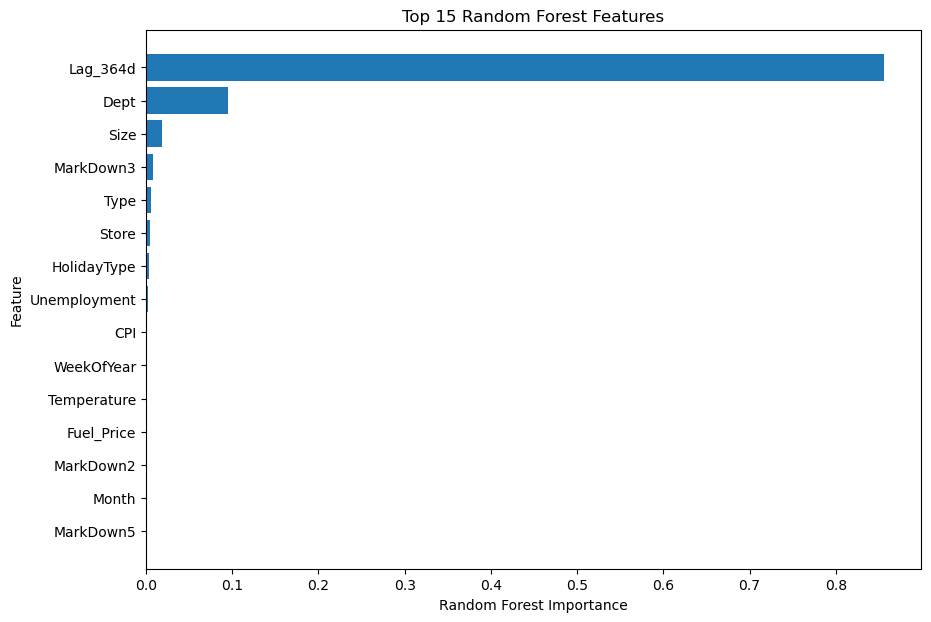

In [20]:
# ============================================================
# 15. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 15.1 Get transformed feature names
# ------------------------------------------------------------

feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)


# ------------------------------------------------------------
# 15.2 Get importance from BEST Random Forest
# ------------------------------------------------------------

importance_values = (
    best_rf_model.feature_importances_
)


encoded_importance = pd.DataFrame({

    "EncodedFeature":
        feature_names,

    "Importance":
        importance_values
})


# ------------------------------------------------------------
# 15.3 Function to recover original feature name
# ------------------------------------------------------------

def get_original_feature(
    encoded_name
):

    # Remove transformer prefix:
    # num__Size -> Size
    # cat__Store_1 -> Store_1
    name = encoded_name.split(
        "__",
        1
    )[-1]


    # Categorical variables were expanded by one-hot encoding.
    for feature in rf_categorical_features:

        if (
            name == feature
            or
            name.startswith(
                feature + "_"
            )
        ):

            return feature


    # Numeric and binary features keep their name.
    return name


encoded_importance[
    "OriginalFeature"
] = (
    encoded_importance[
        "EncodedFeature"
    ]
    .apply(
        get_original_feature
    )
)


# ------------------------------------------------------------
# 15.4 Aggregate one-hot columns
# ------------------------------------------------------------

feature_importance = (
    encoded_importance
    .groupby(
        "OriginalFeature",
        as_index=False
    )["Importance"]
    .sum()
    .sort_values(
        "Importance",
        ascending=False
    )
)


print("=" * 65)
print("AGGREGATED FEATURE IMPORTANCE")
print("=" * 65)

display(
    feature_importance
)


# ------------------------------------------------------------
# 15.5 Top feature plot
# ------------------------------------------------------------

top_features = (
    feature_importance
    .head(15)
    .sort_values(
        "Importance",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features[
        "OriginalFeature"
    ],
    top_features[
        "Importance"
    ]
)

plt.xlabel(
    "Random Forest Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 15 Random Forest Features"
)

plt.show()

In [21]:
# ============================================================
# 16. FEATURE ABLATION STUDY
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


# ============================================================
# 16.1 FEATURE GROUPS
# ============================================================

macro_features = [
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]


markdown_value_features = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]


markdown_missing_features = [
    "MarkDown1_Missing",
    "MarkDown2_Missing",
    "MarkDown3_Missing",
    "MarkDown4_Missing",
    "MarkDown5_Missing"
]


calendar_numeric_features = [
    "Month",
    "WeekOfYear",
    "Quarter"
]


calendar_categorical_features = [
    "HolidayType"
]


calendar_binary_features = [
    "IsHoliday"
]


store_numeric_features = [
    "Size"
]


store_categorical_features = [
    "Store",
    "Type"
]


# ============================================================
# 16.2 MODEL-EVALUATION FUNCTION
# ============================================================

def run_ablation_model(
    name,
    categorical_features,
    binary_features,
    numeric_features
):

    # --------------------------------------------------------
    # Select columns
    # --------------------------------------------------------

    feature_columns = (
        categorical_features
        + binary_features
        + numeric_features
    )


    X_train_ablation = rf_train[
        feature_columns
    ]

    X_val_ablation = rf_validation[
        feature_columns
    ]


    # --------------------------------------------------------
    # Numerical preprocessing
    # --------------------------------------------------------

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            )
        ]
    )


    # --------------------------------------------------------
    # Categorical preprocessing
    # --------------------------------------------------------

    categorical_pipeline = Pipeline(
        steps=[
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )


    # --------------------------------------------------------
    # Combine preprocessing
    # --------------------------------------------------------

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                numeric_features
            ),

            (
                "cat",
                categorical_pipeline,
                categorical_features
            ),

            (
                "binary",
                "passthrough",
                binary_features
            )
        ]
    )


    # --------------------------------------------------------
    # Fit preprocessing on TRAIN only
    # --------------------------------------------------------

    X_train_processed = (
        preprocessor.fit_transform(
            X_train_ablation
        )
    )

    X_val_processed = (
        preprocessor.transform(
            X_val_ablation
        )
    )


    # --------------------------------------------------------
    # Use BEST RF configuration
    # --------------------------------------------------------

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=18,
        min_samples_leaf=10,
        max_features=0.5,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(
        X_train_processed,
        y_rf_train,
        sample_weight=rf_train_weights
    )


    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    predictions = model.predict(
        X_val_processed
    )


    # --------------------------------------------------------
    # Evaluate
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_rf_val,
        predictions
    )


    wmae = weighted_mae(
        y_rf_val,
        predictions,
        rf_validation["IsHoliday"]
    )


    return {
        "Model": name,
        "Features": len(feature_columns),
        "MAE": mae,
        "WMAE": wmae
    }


# ============================================================
# 16.3 FULL MODEL FEATURE LISTS
# ============================================================

full_cat = rf_categorical_features.copy()
full_binary = rf_binary_features.copy()
full_num = rf_numeric_features.copy()


# ============================================================
# 16.4 STORE RESULTS
# ============================================================

ablation_results = []


# ============================================================
# TEST 1 — FULL MODEL
# ============================================================

ablation_results.append(
    run_ablation_model(
        "Full Model",
        full_cat,
        full_binary,
        full_num
    )
)


# ============================================================
# TEST 2 — REMOVE MACROECONOMIC FEATURES
# ============================================================

no_macro_num = [
    feature
    for feature in full_num
    if feature not in macro_features
]


ablation_results.append(
    run_ablation_model(
        "No Macro",
        full_cat,
        full_binary,
        no_macro_num
    )
)


# ============================================================
# TEST 3 — REMOVE MARKDOWN FEATURES
# ============================================================

no_markdown_num = [
    feature
    for feature in full_num
    if feature not in markdown_value_features
]


no_markdown_binary = [
    feature
    for feature in full_binary
    if feature not in markdown_missing_features
]


ablation_results.append(
    run_ablation_model(
        "No Markdowns",
        full_cat,
        no_markdown_binary,
        no_markdown_num
    )
)


# ============================================================
# TEST 4 — REMOVE CALENDAR / HOLIDAY INFORMATION
# ============================================================

no_calendar_num = [
    feature
    for feature in full_num
    if feature not in calendar_numeric_features
]


no_calendar_cat = [
    feature
    for feature in full_cat
    if feature not in calendar_categorical_features
]


no_calendar_binary = [
    feature
    for feature in full_binary
    if feature not in calendar_binary_features
]


ablation_results.append(
    run_ablation_model(
        "No Calendar",
        no_calendar_cat,
        no_calendar_binary,
        no_calendar_num
    )
)


# ============================================================
# TEST 5 — REMOVE STORE METADATA
# ============================================================

no_store_num = [
    feature
    for feature in full_num
    if feature not in store_numeric_features
]


no_store_cat = [
    feature
    for feature in full_cat
    if feature not in store_categorical_features
]


ablation_results.append(
    run_ablation_model(
        "No Store Metadata",
        no_store_cat,
        full_binary,
        no_store_num
    )
)


# ============================================================
# TEST 6 — REMOVE DEPARTMENT
# ============================================================

no_dept_cat = [
    feature
    for feature in full_cat
    if feature != "Dept"
]


ablation_results.append(
    run_ablation_model(
        "No Department",
        no_dept_cat,
        full_binary,
        full_num
    )
)


# ============================================================
# TEST 7 — REMOVE 52-WEEK SALES LAG
# ============================================================

no_lag_num = [
    feature
    for feature in full_num
    if feature != "Lag_364d"
]


ablation_results.append(
    run_ablation_model(
        "No Lag_364d",
        full_cat,
        full_binary,
        no_lag_num
    )
)


# ============================================================
# 16.5 RESULTS TABLE
# ============================================================

ablation_results = pd.DataFrame(
    ablation_results
)


full_model_wmae = (
    ablation_results
    .loc[
        ablation_results["Model"]
        == "Full Model",
        "WMAE"
    ]
    .iloc[0]
)


# Change relative to full model
ablation_results[
    "WMAE_Change"
] = (
    ablation_results["WMAE"]
    - full_model_wmae
)


ablation_results[
    "WMAE_Change_Percent"
] = (
    ablation_results[
        "WMAE_Change"
    ]
    /
    full_model_wmae
) * 100


# Sort best to worst
ablation_results = (
    ablation_results
    .sort_values("WMAE")
    .reset_index(drop=True)
)


print("=" * 80)
print("FEATURE ABLATION RESULTS")
print("=" * 80)


display(
    ablation_results.round(2)
)

KeyboardInterrupt: 

In [ ]:
# ============================================================
# 17. ROLLING TIME-SERIES VALIDATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


# ============================================================
# 17.1 DEFINE TIME-BASED VALIDATION FOLDS
# ============================================================
#
# Each validation period occurs AFTER its training period.
#
# We use approximately 13-week validation windows.
# ============================================================

time_folds = [

    {
        "Fold": "Fold 1",
        "ValidationStart": pd.Timestamp("2012-01-20"),
        "ValidationEnd": pd.Timestamp("2012-04-13")
    },

    {
        "Fold": "Fold 2",
        "ValidationStart": pd.Timestamp("2012-04-27"),
        "ValidationEnd": pd.Timestamp("2012-07-20")
    },

    {
        "Fold": "Fold 3",
        "ValidationStart": pd.Timestamp("2012-08-03"),
        "ValidationEnd": pd.Timestamp("2012-10-26")
    }
]


# ============================================================
# 17.2 DEFINE FEATURE SETS
# ============================================================


# ------------------------------------------------------------
# MODEL A — FULL MODEL
# ------------------------------------------------------------

full_features = {

    "categorical": [
        "Store",
        "Dept",
        "Type",
        "HolidayType"
    ],

    "binary": [
        "IsHoliday",
        "MarkDown1_Missing",
        "MarkDown2_Missing",
        "MarkDown3_Missing",
        "MarkDown4_Missing",
        "MarkDown5_Missing"
    ],

    "numeric": [
        "Size",
        "Temperature",
        "Fuel_Price",
        "CPI",
        "Unemployment",

        "MarkDown1",
        "MarkDown2",
        "MarkDown3",
        "MarkDown4",
        "MarkDown5",

        "Lag_364d",

        "Month",
        "WeekOfYear",
        "Quarter"
    ]
}


# ------------------------------------------------------------
# MODEL B — NO CALENDAR
# ------------------------------------------------------------
#
# Removes:
#
# Month
# WeekOfYear
# Quarter
# HolidayType
# IsHoliday
#
# IMPORTANT:
# IsHoliday is still used for sample weighting and WMAE.
# It is simply not provided as a predictor.
# ------------------------------------------------------------

no_calendar_features = {

    "categorical": [
        "Store",
        "Dept",
        "Type"
    ],

    "binary": [
        "MarkDown1_Missing",
        "MarkDown2_Missing",
        "MarkDown3_Missing",
        "MarkDown4_Missing",
        "MarkDown5_Missing"
    ],

    "numeric": [
        "Size",
        "Temperature",
        "Fuel_Price",
        "CPI",
        "Unemployment",

        "MarkDown1",
        "MarkDown2",
        "MarkDown3",
        "MarkDown4",
        "MarkDown5",

        "Lag_364d"
    ]
}


candidate_models = {

    "Full Model":
        full_features,

    "No Calendar":
        no_calendar_features
}


# ============================================================
# 17.3 MODEL TRAINING FUNCTION
# ============================================================

def evaluate_rf_fold(
    fold_train,
    fold_validation,
    feature_config
):

    categorical = (
        feature_config[
            "categorical"
        ]
    )

    binary = (
        feature_config[
            "binary"
        ]
    )

    numeric = (
        feature_config[
            "numeric"
        ]
    )


    all_features = (
        categorical
        + binary
        + numeric
    )


    # --------------------------------------------------------
    # X / y
    # --------------------------------------------------------

    X_train_fold = fold_train[
        all_features
    ]

    y_train_fold = fold_train[
        "Weekly_Sales"
    ]


    X_val_fold = fold_validation[
        all_features
    ]

    y_val_fold = fold_validation[
        "Weekly_Sales"
    ]


    # --------------------------------------------------------
    # Numerical preprocessing
    # --------------------------------------------------------

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            )
        ]
    )


    # --------------------------------------------------------
    # Categorical preprocessing
    # --------------------------------------------------------

    categorical_pipeline = Pipeline(
        steps=[
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )


    # --------------------------------------------------------
    # Column preprocessing
    # --------------------------------------------------------

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                numeric
            ),

            (
                "cat",
                categorical_pipeline,
                categorical
            ),

            (
                "binary",
                "passthrough",
                binary
            )
        ]
    )


    # --------------------------------------------------------
    # Fit preprocessing ONLY on historical training data
    # --------------------------------------------------------

    X_train_processed = (
        preprocessor.fit_transform(
            X_train_fold
        )
    )


    X_val_processed = (
        preprocessor.transform(
            X_val_fold
        )
    )


    # --------------------------------------------------------
    # Random Forest
    #
    # Best configuration discovered previously:
    #
    # max_depth = 18
    # min_samples_leaf = 10
    # max_features = 0.5
    # --------------------------------------------------------

    model = RandomForestRegressor(

        n_estimators=100,

        max_depth=18,

        min_samples_leaf=10,

        max_features=0.5,

        bootstrap=True,

        random_state=42,

        n_jobs=-1
    )


    # --------------------------------------------------------
    # Holiday weights
    # --------------------------------------------------------

    train_weights = np.where(
        fold_train["IsHoliday"],
        5,
        1
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(

        X_train_processed,

        y_train_fold,

        sample_weight=train_weights
    )


    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    predictions = model.predict(
        X_val_processed
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_val_fold,
        predictions
    )


    wmae = weighted_mae(
        y_val_fold,
        predictions,
        fold_validation[
            "IsHoliday"
        ]
    )


    return mae, wmae


# ============================================================
# 17.4 RUN ROLLING VALIDATION
# ============================================================

rolling_results = []


for fold in time_folds:

    fold_name = fold["Fold"]

    validation_start = (
        fold["ValidationStart"]
    )

    validation_end = (
        fold["ValidationEnd"]
    )


    print("\n" + "=" * 70)

    print(
        fold_name,
        ":",
        validation_start.date(),
        "to",
        validation_end.date()
    )

    print("=" * 70)


    # --------------------------------------------------------
    # Training data
    #
    # Only observations BEFORE validation.
    #
    # Also require an exact 52-week lag because this model
    # depends on Lag_364d.
    # --------------------------------------------------------

    fold_train = ml_data_clean[

        (
            ml_data_clean["Date"]
            < validation_start
        )

        &

        (
            ml_data_clean[
                "Lag_364d"
            ].notna()
        )

    ].copy()


    # --------------------------------------------------------
    # Validation data
    # --------------------------------------------------------

    fold_validation = ml_data_clean[

        (
            ml_data_clean["Date"]
            >= validation_start
        )

        &

        (
            ml_data_clean["Date"]
            <= validation_end
        )

        &

        (
            ml_data_clean[
                "Lag_364d"
            ].notna()
        )

    ].copy()


    print(
        "Training rows:",
        len(fold_train)
    )

    print(
        "Validation rows:",
        len(fold_validation)
    )


    # ========================================================
    # BASELINE
    # ========================================================
    #
    # Exact seasonal baseline:
    #
    # Prediction = sales exactly 364 days earlier
    # ========================================================

    baseline_predictions = (
        fold_validation[
            "Lag_364d"
        ]
    )


    baseline_mae_fold = (
        mean_absolute_error(

            fold_validation[
                "Weekly_Sales"
            ],

            baseline_predictions
        )
    )


    baseline_wmae_fold = (
        weighted_mae(

            fold_validation[
                "Weekly_Sales"
            ],

            baseline_predictions,

            fold_validation[
                "IsHoliday"
            ]
        )
    )


    rolling_results.append({

        "Fold":
            fold_name,

        "Model":
            "Seasonal Baseline",

        "MAE":
            baseline_mae_fold,

        "WMAE":
            baseline_wmae_fold,

        "Improvement_vs_Baseline":
            0.0
    })


    print(
        "Baseline WMAE:",
        round(
            baseline_wmae_fold,
            2
        )
    )


    # ========================================================
    # TEST CANDIDATE MODELS
    # ========================================================

    for (
        model_name,
        feature_config
    ) in candidate_models.items():


        print(
            "Testing:",
            model_name
        )


        mae, wmae = evaluate_rf_fold(

            fold_train,

            fold_validation,

            feature_config
        )


        improvement = (

            (
                baseline_wmae_fold
                - wmae
            )

            /

            baseline_wmae_fold

        ) * 100


        rolling_results.append({

            "Fold":
                fold_name,

            "Model":
                model_name,

            "MAE":
                mae,

            "WMAE":
                wmae,

            "Improvement_vs_Baseline":
                improvement
        })


# ============================================================
# 17.5 RESULTS TABLE
# ============================================================

rolling_results = pd.DataFrame(
    rolling_results
)


print("\n" + "=" * 80)
print("ROLLING VALIDATION RESULTS")
print("=" * 80)


display(
    rolling_results.round(2)
)


# ============================================================
# 17.6 SUMMARY ACROSS FOLDS
# ============================================================

rolling_summary = (

    rolling_results

    .groupby("Model")

    .agg(

        Mean_MAE=(
            "MAE",
            "mean"
        ),

        Mean_WMAE=(
            "WMAE",
            "mean"
        ),

        Std_WMAE=(
            "WMAE",
            "std"
        ),

        Mean_Improvement=(
            "Improvement_vs_Baseline",
            "mean"
        )
    )

    .sort_values(
        "Mean_WMAE"
    )

    .reset_index()
)


print("\n" + "=" * 80)
print("ROLLING VALIDATION SUMMARY")
print("=" * 80)


display(
    rolling_summary.round(2)
)


Fold 1 : 2012-01-20 to 2012-04-13
Training rows: 143375
Validation rows: 37507
Baseline WMAE: 1858.36
Testing: Full Model
Testing: No Calendar

Fold 2 : 2012-04-27 to 2012-07-20
Training rows: 183778
Validation rows: 37329
Baseline WMAE: 1833.64
Testing: Full Model
Testing: No Calendar

Fold 3 : 2012-08-03 to 2012-10-26
Training rows: 223951
Validation rows: 37590
Baseline WMAE: 1736.12
Testing: Full Model
Testing: No Calendar

ROLLING VALIDATION RESULTS


,Fold,Model,MAE,WMAE,Improvement_vs_Baseline
0,Fold 1,Seasonal Baseline,1849.45,1858.36,0.00
1,Fold 1,Full Model,1691.40,1712.06,7.87
2,Fold 1,No Calendar,1666.01,1674.75,9.88
3,Fold 2,Seasonal Baseline,1833.64,1833.64,0.00
4,Fold 2,Full Model,1661.94,1661.94,9.36
5,Fold 2,No Calendar,1689.90,1689.90,7.84
6,Fold 3,Seasonal Baseline,1710.81,1736.12,0.00
7,Fold 3,Full Model,1566.66,1566.71,9.76
8,Fold 3,No Calendar,1561.85,1560.97,10.09



ROLLING VALIDATION SUMMARY


,Model,Mean_MAE,Mean_WMAE,Std_WMAE,Mean_Improvement
0,No Calendar,1639.25,1641.87,70.47,9.27
1,Full Model,1640.00,1646.90,73.83,9.00
2,Seasonal Baseline,1797.97,1809.37,64.63,0.00


In [ ]:
# ============================================================
# 18. XGBOOST - ROLLING TIME-SERIES VALIDATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error

from xgboost import XGBRegressor


# ============================================================
# 18.1 FEATURE SET
# ============================================================
#
# We use the No-Calendar feature set because it produced
# the best mean Random Forest performance across our
# rolling validation folds.
# ============================================================

xgb_categorical_features = [
    "Store",
    "Dept",
    "Type"
]


xgb_binary_features = [
    "MarkDown1_Missing",
    "MarkDown2_Missing",
    "MarkDown3_Missing",
    "MarkDown4_Missing",
    "MarkDown5_Missing"
]


xgb_numeric_features = [
    "Size",

    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",

    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",

    "Lag_364d"
]


xgb_feature_columns = (
    xgb_categorical_features
    + xgb_binary_features
    + xgb_numeric_features
)


# ============================================================
# 18.2 FUNCTION TO TRAIN ONE XGBOOST FOLD
# ============================================================

def evaluate_xgb_fold(
    fold_train,
    fold_validation
):

    # --------------------------------------------------------
    # X / y
    # --------------------------------------------------------

    X_train = fold_train[
        xgb_feature_columns
    ]

    y_train = fold_train[
        "Weekly_Sales"
    ]


    X_val = fold_validation[
        xgb_feature_columns
    ]

    y_val = fold_validation[
        "Weekly_Sales"
    ]


    # --------------------------------------------------------
    # Numerical preprocessing
    # --------------------------------------------------------

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            )
        ]
    )


    # --------------------------------------------------------
    # Categorical preprocessing
    # --------------------------------------------------------

    categorical_pipeline = Pipeline(
        steps=[
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )


    # --------------------------------------------------------
    # Combine preprocessing
    # --------------------------------------------------------

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                xgb_numeric_features
            ),

            (
                "cat",
                categorical_pipeline,
                xgb_categorical_features
            ),

            (
                "binary",
                "passthrough",
                xgb_binary_features
            )
        ]
    )


    # --------------------------------------------------------
    # Fit preprocessing ONLY on training data
    # --------------------------------------------------------

    X_train_processed = (
        preprocessor.fit_transform(
            X_train
        )
    )


    X_val_processed = (
        preprocessor.transform(
            X_val
        )
    )


    # --------------------------------------------------------
    # Holiday weights
    #
    # Holiday = 5
    # Normal  = 1
    #
    # This aligns training more closely with WMAE.
    # --------------------------------------------------------

    train_weights = np.where(
        fold_train["IsHoliday"],
        5,
        1
    )


    # --------------------------------------------------------
    # XGBoost model
    # --------------------------------------------------------
    #
    # These are STARTING hyperparameters.
    # They are not claimed to be optimal.
    # --------------------------------------------------------

    model = XGBRegressor(

        # Number of boosting trees
        n_estimators=300,

        # Contribution of each individual tree
        learning_rate=0.05,

        # Complexity of each tree
        max_depth=8,

        # Minimum child weight reduces overly-specific splits
        min_child_weight=10,

        # Train each tree on 80% of observations
        subsample=0.8,

        # Each tree sees 70% of feature columns
        colsample_bytree=0.7,

        # L2 regularization
        reg_lambda=10,

        # Small L1 regularization
        reg_alpha=0.1,

        # Regression objective
        objective="reg:squarederror",

        # Efficient tree construction
        tree_method="hist",

        random_state=42,

        n_jobs=-1
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(
        X_train_processed,
        y_train,
        sample_weight=train_weights
    )


    # --------------------------------------------------------
    # Training predictions
    # --------------------------------------------------------

    train_predictions = model.predict(
        X_train_processed
    )


    # --------------------------------------------------------
    # Validation predictions
    # --------------------------------------------------------

    validation_predictions = model.predict(
        X_val_processed
    )


    # --------------------------------------------------------
    # Training metrics
    # --------------------------------------------------------

    train_mae = mean_absolute_error(
        y_train,
        train_predictions
    )


    train_wmae = weighted_mae(
        y_train,
        train_predictions,
        fold_train["IsHoliday"]
    )


    # --------------------------------------------------------
    # Validation metrics
    # --------------------------------------------------------

    validation_mae = mean_absolute_error(
        y_val,
        validation_predictions
    )


    validation_wmae = weighted_mae(
        y_val,
        validation_predictions,
        fold_validation["IsHoliday"]
    )


    return {
        "Train_MAE": train_mae,
        "Train_WMAE": train_wmae,

        "Validation_MAE":
            validation_mae,

        "Validation_WMAE":
            validation_wmae,

        "Model":
            model,

        "Preprocessor":
            preprocessor
    }


# ============================================================
# 18.3 RUN XGBOOST THROUGH THE SAME TIME FOLDS
# ============================================================

xgb_results = []

best_xgb_model = None
best_xgb_preprocessor = None
best_xgb_wmae = np.inf


for fold in time_folds:

    fold_name = fold[
        "Fold"
    ]

    validation_start = fold[
        "ValidationStart"
    ]

    validation_end = fold[
        "ValidationEnd"
    ]


    print("\n" + "=" * 70)

    print(
        fold_name,
        ":",
        validation_start.date(),
        "to",
        validation_end.date()
    )

    print("=" * 70)


    # --------------------------------------------------------
    # Historical training data only
    # --------------------------------------------------------

    fold_train = ml_data_clean[

        (
            ml_data_clean["Date"]
            < validation_start
        )

        &

        (
            ml_data_clean[
                "Lag_364d"
            ].notna()
        )

    ].copy()


    # --------------------------------------------------------
    # Future validation period
    # --------------------------------------------------------

    fold_validation = ml_data_clean[

        (
            ml_data_clean["Date"]
            >= validation_start
        )

        &

        (
            ml_data_clean["Date"]
            <= validation_end
        )

        &

        (
            ml_data_clean[
                "Lag_364d"
            ].notna()
        )

    ].copy()


    print(
        "Training rows:",
        len(fold_train)
    )

    print(
        "Validation rows:",
        len(fold_validation)
    )


    # --------------------------------------------------------
    # Seasonal baseline
    # --------------------------------------------------------

    baseline_predictions = (
        fold_validation[
            "Lag_364d"
        ]
    )


    baseline_wmae = weighted_mae(

        fold_validation[
            "Weekly_Sales"
        ],

        baseline_predictions,

        fold_validation[
            "IsHoliday"
        ]
    )


    # --------------------------------------------------------
    # XGBoost
    # --------------------------------------------------------

    results = evaluate_xgb_fold(
        fold_train,
        fold_validation
    )


    xgb_wmae = results[
        "Validation_WMAE"
    ]


    improvement = (

        (
            baseline_wmae
            - xgb_wmae
        )

        /

        baseline_wmae

    ) * 100


    generalization_gap = (
        xgb_wmae
        - results[
            "Train_WMAE"
        ]
    )


    xgb_results.append({

        "Fold":
            fold_name,

        "Baseline_WMAE":
            baseline_wmae,

        "Train_MAE":
            results[
                "Train_MAE"
            ],

        "Train_WMAE":
            results[
                "Train_WMAE"
            ],

        "Validation_MAE":
            results[
                "Validation_MAE"
            ],

        "Validation_WMAE":
            xgb_wmae,

        "Gap":
            generalization_gap,

        "Improvement_vs_Baseline":
            improvement
    })


    # --------------------------------------------------------
    # Store best fold model
    # --------------------------------------------------------

    if xgb_wmae < best_xgb_wmae:

        best_xgb_wmae = xgb_wmae

        best_xgb_model = results[
            "Model"
        ]

        best_xgb_preprocessor = results[
            "Preprocessor"
        ]


# ============================================================
# 18.4 XGBOOST RESULTS TABLE
# ============================================================

xgb_results = pd.DataFrame(
    xgb_results
)


print("\n" + "=" * 80)

print(
    "XGBOOST ROLLING VALIDATION RESULTS"
)

print("=" * 80)


display(
    xgb_results.round(2)
)


# ============================================================
# 18.5 XGBOOST SUMMARY
# ============================================================

xgb_summary = pd.DataFrame({

    "Mean_MAE": [
        xgb_results[
            "Validation_MAE"
        ].mean()
    ],

    "Mean_WMAE": [
        xgb_results[
            "Validation_WMAE"
        ].mean()
    ],

    "Std_WMAE": [
        xgb_results[
            "Validation_WMAE"
        ].std()
    ],

    "Mean_Improvement": [
        xgb_results[
            "Improvement_vs_Baseline"
        ].mean()
    ],

    "Mean_Train_WMAE": [
        xgb_results[
            "Train_WMAE"
        ].mean()
    ]
})


print("\n" + "=" * 80)

print(
    "XGBOOST SUMMARY"
)

print("=" * 80)


display(
    xgb_summary.round(2)
)


# ============================================================
# 18.6 FINAL RF VS XGBOOST COMPARISON
# ============================================================

rf_no_calendar_summary = (
    rolling_summary[
        rolling_summary["Model"]
        == "No Calendar"
    ]
)


rf_mean_wmae = (
    rf_no_calendar_summary[
        "Mean_WMAE"
    ].iloc[0]
)


rf_mean_improvement = (
    rf_no_calendar_summary[
        "Mean_Improvement"
    ].iloc[0]
)


print("\n" + "=" * 80)

print(
    "RANDOM FOREST VS XGBOOST"
)

print("=" * 80)


print(
    "Random Forest Mean WMAE:",
    round(
        rf_mean_wmae,
        2
    )
)

print(
    "Random Forest Mean Improvement:",
    round(
        rf_mean_improvement,
        2
    ),
    "%"
)


print()


print(
    "XGBoost Mean WMAE:",
    round(
        xgb_results[
            "Validation_WMAE"
        ].mean(),
        2
    )
)

print(
    "XGBoost Mean Improvement:",
    round(
        xgb_results[
            "Improvement_vs_Baseline"
        ].mean(),
        2
    ),
    "%"
)


Fold 1 : 2012-01-20 to 2012-04-13
Training rows: 143375
Validation rows: 37507

Fold 2 : 2012-04-27 to 2012-07-20
Training rows: 183778
Validation rows: 37329

Fold 3 : 2012-08-03 to 2012-10-26
Training rows: 223951
Validation rows: 37590

XGBOOST ROLLING VALIDATION RESULTS


,Fold,Baseline_WMAE,Train_MAE,Train_WMAE,Validation_MAE,Validation_WMAE,Gap,Improvement_vs_Baseline
0,Fold 1,1858.36,1450.19,1421.89,1743.07,1771.68,349.79,4.66
1,Fold 2,1833.64,1466.78,1442.24,1768.21,1768.21,325.97,3.57
2,Fold 3,1736.12,1470.43,1450.17,1605.19,1607.20,157.03,7.43



XGBOOST SUMMARY


,Mean_MAE,Mean_WMAE,Std_WMAE,Mean_Improvement,Mean_Train_WMAE
0,1705.49,1715.69,93.97,5.22,1438.1



RANDOM FOREST VS XGBOOST
Random Forest Mean WMAE: 1641.87
Random Forest Mean Improvement: 9.27 %

XGBoost Mean WMAE: 1715.69
XGBoost Mean Improvement: 5.22 %


In [26]:
# ============================================================
# 19. FINAL RANDOM FOREST MODEL + TEST FORECASTING
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor


# ============================================================
# 19.1 CREATE FINAL TRAINING DATA
# ============================================================
#
# ml_data_clean already contains:
#
# - integrated historical data
# - exact Lag_364d
# - markdown values
# - markdown missing indicators
#
# For our selected lag-based model, use only rows where the
# true 52-week historical sales value exists.
# ============================================================

final_train = ml_data_clean[
    ml_data_clean["Lag_364d"].notna()
].copy()


print(
    "Final training rows:",
    len(final_train)
)


# ============================================================
# 19.2 PREPARE TEST DATA
# ============================================================
#
# test_features came from our previous feature-engineering
# step and already contains:
#
# Store
# Dept
# Date
# IsHoliday
# Type
# Size
# macro variables
# markdown variables
# markdown missing indicators
# ============================================================

final_test = test_features.copy()


# ============================================================
# 19.3 BUILD EXACT 52-WEEK SALES LOOKUP
# ============================================================
#
# We can only obtain Weekly_Sales from historical training data.
#
# Example:
#
# Historical:
# 2011-11-04 -> sales
#
# Move forward 52 weeks:
# 2012-11-02 -> Lag_364d
#
# This allows test observations to use sales from exactly
# 52 weeks earlier.
# ============================================================

test_lag_lookup = train_merged[
    [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales"
    ]
].copy()


test_lag_lookup["Date"] = (
    test_lag_lookup["Date"]
    + pd.Timedelta(weeks=52)
)


test_lag_lookup = test_lag_lookup.rename(
    columns={
        "Weekly_Sales":
        "Lag_364d"
    }
)


# Attach historical lag to test data
final_test = final_test.merge(
    test_lag_lookup,

    on=[
        "Store",
        "Dept",
        "Date"
    ],

    how="left",

    validate="one_to_one"
)


print(
    "Test rows:",
    len(final_test)
)

print(
    "Test rows with exact 52-week lag:",
    final_test[
        "Lag_364d"
    ].notna().sum()
)

print(
    "Test rows without exact lag:",
    final_test[
        "Lag_364d"
    ].isna().sum()
)


# ============================================================
# 19.4 FINAL FEATURE SET
# ============================================================
#
# Selected from rolling validation:
# NO explicit calendar predictor variables.
#
# Note:
# IsHoliday is still used to weight training observations,
# but is NOT directly provided to the model.
# ============================================================

final_categorical_features = [
    "Store",
    "Dept",
    "Type"
]


final_binary_features = [
    "MarkDown1_Missing",
    "MarkDown2_Missing",
    "MarkDown3_Missing",
    "MarkDown4_Missing",
    "MarkDown5_Missing"
]


final_numeric_features = [
    "Size",

    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",

    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",

    "Lag_364d"
]


final_feature_columns = (
    final_categorical_features
    + final_binary_features
    + final_numeric_features
)


# ============================================================
# 19.5 CREATE TRAINING MATRIX
# ============================================================

X_final_train = final_train[
    final_feature_columns
]

y_final_train = final_train[
    "Weekly_Sales"
]


# ============================================================
# 19.6 ONLY TEST ROWS WITH EXACT LAG GO THROUGH RF
# ============================================================

test_with_lag = final_test[
    final_test["Lag_364d"].notna()
].copy()


X_final_test = test_with_lag[
    final_feature_columns
]


# ============================================================
# 19.7 NUMERICAL PREPROCESSING
# ============================================================
#
# The test set contains missing CPI and Unemployment values.
#
# Median imputation here is learned ONLY from training data
# because the preprocessor is fitted on X_final_train.
# ============================================================

final_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


# ============================================================
# 19.8 CATEGORICAL PREPROCESSING
# ============================================================

final_categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ============================================================
# 19.9 COMBINE PREPROCESSING
# ============================================================

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            final_numeric_pipeline,
            final_numeric_features
        ),

        (
            "cat",
            final_categorical_pipeline,
            final_categorical_features
        ),

        (
            "binary",
            "passthrough",
            final_binary_features
        )
    ]
)


# Fit ONLY using historical training data
X_final_train_processed = (
    final_preprocessor.fit_transform(
        X_final_train
    )
)


# Apply same transformations to future test data
X_final_test_processed = (
    final_preprocessor.transform(
        X_final_test
    )
)


print(
    "Processed training shape:",
    X_final_train_processed.shape
)

print(
    "Processed test shape:",
    X_final_test_processed.shape
)


# ============================================================
# 19.10 FINAL RANDOM FOREST
# ============================================================
#
# Best configuration established through:
#
# - controlled hyperparameter testing
# - rolling time-series validation
#
# ============================================================

final_rf_model = RandomForestRegressor(

    n_estimators=100,

    max_depth=18,

    min_samples_leaf=10,

    max_features=0.5,

    bootstrap=True,

    random_state=42,

    n_jobs=-1
)


# ============================================================
# 19.11 HOLIDAY SAMPLE WEIGHTS
# ============================================================
#
# Even though IsHoliday is not a predictor, it can still
# influence training through sample weighting.
#
# Holiday observations receive 5x importance because this
# matches the WMAE business/evaluation objective.
# ============================================================

final_train_weights = np.where(
    final_train["IsHoliday"],
    5,
    1
)


# ============================================================
# 19.12 TRAIN FINAL MODEL
# ============================================================

final_rf_model.fit(
    X_final_train_processed,

    y_final_train,

    sample_weight=final_train_weights
)


# ============================================================
# 19.13 PREDICT TEST ROWS WITH EXACT LAG
# ============================================================

test_rf_predictions = (
    final_rf_model.predict(
        X_final_test_processed
    )
)


test_with_lag[
    "Predicted_Weekly_Sales"
] = test_rf_predictions


# ============================================================
# 19.14 FALLBACK FOR ROWS WITHOUT EXACT LAG
# ============================================================
#
# For Store-Department combinations without exact prior-year
# sales, use historical Store-Department median.
#
# IMPORTANT:
# These medians come ONLY from historical train data.
# ============================================================

store_dept_final_median = (
    train_merged
    .groupby(
        [
            "Store",
            "Dept"
        ]
    )["Weekly_Sales"]
    .median()
    .rename(
        "StoreDeptMedian"
    )
    .reset_index()
)


global_final_median = (
    train_merged[
        "Weekly_Sales"
    ]
    .median()
)


test_without_lag = final_test[
    final_test[
        "Lag_364d"
    ].isna()
].copy()


test_without_lag = (
    test_without_lag
    .merge(
        store_dept_final_median,

        on=[
            "Store",
            "Dept"
        ],

        how="left",

        validate="many_to_one"
    )
)


test_without_lag[
    "Predicted_Weekly_Sales"
] = (
    test_without_lag[
        "StoreDeptMedian"
    ]
    .fillna(
        global_final_median
    )
)


# ============================================================
# 19.15 RECORD PREDICTION SOURCE
# ============================================================

test_with_lag[
    "PredictionSource"
] = "RandomForest"


test_without_lag[
    "PredictionSource"
] = "HistoricalMedianFallback"


# ============================================================
# 19.16 COMBINE ALL TEST PREDICTIONS
# ============================================================

prediction_columns = [
    "Store",
    "Dept",
    "Date",
    "IsHoliday",
    "Predicted_Weekly_Sales",
    "PredictionSource"
]


final_predictions = pd.concat(
    [
        test_with_lag[
            prediction_columns
        ],

        test_without_lag[
            prediction_columns
        ]
    ],

    ignore_index=True
)


# Restore chronological/original logical ordering
final_predictions = (
    final_predictions
    .sort_values(
        [
            "Store",
            "Dept",
            "Date"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 19.17 VALIDATE OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("FINAL FORECAST SUMMARY")
print("=" * 70)


print(
    "Expected test rows:",
    len(test)
)

print(
    "Generated predictions:",
    len(final_predictions)
)


print(
    "\nMissing predictions:",
    final_predictions[
        "Predicted_Weekly_Sales"
    ].isna().sum()
)


print(
    "\nPrediction source:"
)

print(
    final_predictions[
        "PredictionSource"
    ].value_counts()
)


print(
    "\nForecast distribution:"
)

print(
    final_predictions[
        "Predicted_Weekly_Sales"
    ].describe()
)


# ============================================================
# 19.18 PREVIEW
# ============================================================

display(
    final_predictions.head(20)
)


# ============================================================
# 19.19 EXPORT FORECASTS
# ============================================================

final_predictions.to_csv(
    "retail_sales_forecasts.csv",
    index=False
)


print(
    "\nSaved: retail_sales_forecasts.csv"
)

Final training rows: 261541
Test rows: 115064
Test rows with exact 52-week lag: 113023
Test rows without exact lag: 2041
Processed training shape: (261541, 143)
Processed test shape: (113023, 143)

FINAL FORECAST SUMMARY
Expected test rows: 115064
Generated predictions: 115064

Missing predictions: 0

Prediction source:
PredictionSource
RandomForest                113023
HistoricalMedianFallback      2041
Name: count, dtype: int64

Forecast distribution:
count    115064.000000
mean      16744.624466
std       23429.095366
min        -143.000000
25%        2203.542406
50%        7867.117944
75%       21383.665764
max      331733.947972
Name: Predicted_Weekly_Sales, dtype: float64


,Store,Dept,Date,IsHoliday,Predicted_Weekly_Sales,PredictionSource
0,1,1,2012-11-02,False,40325.445173,RandomForest
1,1,1,2012-11-09,False,19777.173121,RandomForest
2,1,1,2012-11-16,False,20908.434557,RandomForest
3,1,1,2012-11-23,True,21468.402398,RandomForest
4,1,1,2012-11-30,False,26131.913339,RandomForest
5,1,1,2012-12-07,False,35022.126320,RandomForest
6,1,1,2012-12-14,False,43389.118531,RandomForest
7,1,1,2012-12-21,False,45262.966420,RandomForest
8,1,1,2012-12-28,True,25595.031333,RandomForest
9,1,1,2013-01-04,False,18648.910230,RandomForest



Saved: retail_sales_forecasts.csv


In [27]:
# ============================================================
# 20. FINAL FORECAST QUALITY ASSURANCE
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# Basic integrity checks
# ------------------------------------------------------------

duplicate_predictions = (
    final_predictions
    .duplicated(
        subset=[
            "Store",
            "Dept",
            "Date"
        ]
    )
    .sum()
)


missing_predictions = (
    final_predictions[
        "Predicted_Weekly_Sales"
    ]
    .isna()
    .sum()
)


negative_predictions = (
    final_predictions[
        "Predicted_Weekly_Sales"
    ]
    < 0
).sum()


zero_predictions = (
    final_predictions[
        "Predicted_Weekly_Sales"
    ]
    == 0
).sum()


rf_rows = (
    final_predictions[
        "PredictionSource"
    ]
    == "RandomForest"
).sum()


fallback_rows = (
    final_predictions[
        "PredictionSource"
    ]
    == "HistoricalMedianFallback"
).sum()


rf_coverage = (
    rf_rows
    / len(final_predictions)
) * 100


fallback_coverage = (
    fallback_rows
    / len(final_predictions)
) * 100


print("=" * 65)
print("FINAL FORECAST QA")
print("=" * 65)

print(
    "Expected rows:",
    len(test)
)

print(
    "Forecast rows:",
    len(final_predictions)
)

print(
    "Duplicate Store-Dept-Date keys:",
    duplicate_predictions
)

print(
    "Missing forecasts:",
    missing_predictions
)

print(
    "Negative forecasts:",
    negative_predictions
)

print(
    "Zero forecasts:",
    zero_predictions
)

print()

print(
    "Minimum forecast:",
    round(
        final_predictions[
            "Predicted_Weekly_Sales"
        ].min(),
        2
    )
)

print(
    "Maximum forecast:",
    round(
        final_predictions[
            "Predicted_Weekly_Sales"
        ].max(),
        2
    )
)

print()

print(
    "Random Forest coverage:",
    round(
        rf_coverage,
        2
    ),
    "%"
)

print(
    "Fallback coverage:",
    round(
        fallback_coverage,
        2
    ),
    "%"
)


# ------------------------------------------------------------
# Verify that every test key exists exactly once
# ------------------------------------------------------------

test_keys = (
    test[
        [
            "Store",
            "Dept",
            "Date"
        ]
    ]
    .drop_duplicates()
)


forecast_keys = (
    final_predictions[
        [
            "Store",
            "Dept",
            "Date"
        ]
    ]
    .drop_duplicates()
)


key_check = test_keys.merge(
    forecast_keys,

    on=[
        "Store",
        "Dept",
        "Date"
    ],

    how="outer",

    indicator=True
)


print(
    "\nKey alignment:"
)

print(
    key_check[
        "_merge"
    ].value_counts()
)


# ------------------------------------------------------------
# Automated assertions
# ------------------------------------------------------------

assert len(final_predictions) == len(test)

assert duplicate_predictions == 0

assert missing_predictions == 0

assert (
    key_check["_merge"]
    == "both"
).all()


print(
    "\nAll structural QA checks passed."
)

FINAL FORECAST QA
Expected rows: 115064
Forecast rows: 115064
Duplicate Store-Dept-Date keys: 0
Missing forecasts: 0
Negative forecasts: 78
Zero forecasts: 8

Minimum forecast: -143.0
Maximum forecast: 331733.95

Random Forest coverage: 98.23 %
Fallback coverage: 1.77 %

Key alignment:
_merge
both          115064
left_only          0
right_only         0
Name: count, dtype: int64

All structural QA checks passed.


In [28]:
# ============================================================
# 21. NEGATIVE FORECAST AUDIT
# ============================================================

negative_forecasts = (
    final_predictions[
        final_predictions[
            "Predicted_Weekly_Sales"
        ] < 0
    ]
    .copy()
)


print("=" * 65)
print("NEGATIVE FORECAST AUDIT")
print("=" * 65)

print(
    "Negative forecasts:",
    len(negative_forecasts)
)

print(
    "Percentage:",
    round(
        len(negative_forecasts)
        / len(final_predictions)
        * 100,
        4
    ),
    "%"
)


print("\nPrediction source:")

print(
    negative_forecasts[
        "PredictionSource"
    ].value_counts()
)


print("\nNegative forecast distribution:")

print(
    negative_forecasts[
        "Predicted_Weekly_Sales"
    ].describe()
)


print("\nDepartments with most negative forecasts:")

display(
    negative_forecasts[
        "Dept"
    ]
    .value_counts()
    .head(15)
    .rename_axis("Dept")
    .reset_index(
        name="NegativeForecastCount"
    )
)


print("\nSample negative forecasts:")

display(
    negative_forecasts[
        [
            "Store",
            "Dept",
            "Date",
            "IsHoliday",
            "Predicted_Weekly_Sales",
            "PredictionSource"
        ]
    ]
    .sort_values(
        "Predicted_Weekly_Sales"
    )
    .head(30)
)

NEGATIVE FORECAST AUDIT
Negative forecasts: 78
Percentage: 0.0678 %

Prediction source:
PredictionSource
HistoricalMedianFallback    78
Name: count, dtype: int64

Negative forecast distribution:
count     78.000000
mean     -17.827115
std       18.098807
min     -143.000000
25%      -25.000000
50%      -13.440000
75%       -6.940000
max       -2.500000
Name: Predicted_Weekly_Sales, dtype: float64

Departments with most negative forecasts:


,Dept,NegativeForecastCount
0,47,36
1,19,21
2,72,14
3,33,4
4,55,2
5,37,1



Sample negative forecasts:


,Store,Dept,Date,IsHoliday,Predicted_Weekly_Sales,PredictionSource
88916,34,47,2013-07-12,False,-143.000,HistoricalMedianFallback
31028,12,47,2013-01-18,False,-52.000,HistoricalMedianFallback
31027,12,47,2012-12-21,False,-52.000,HistoricalMedianFallback
63439,24,47,2013-02-22,False,-41.420,HistoricalMedianFallback
63437,24,47,2012-12-28,True,-41.420,HistoricalMedianFallback
63438,24,47,2013-01-18,False,-41.420,HistoricalMedianFallback
39189,15,47,2012-12-14,False,-28.000,HistoricalMedianFallback
39188,15,47,2012-11-23,True,-28.000,HistoricalMedianFallback
39190,15,47,2012-12-21,False,-28.000,HistoricalMedianFallback
25530,10,47,2013-04-19,False,-26.500,HistoricalMedianFallback


In [29]:
# ============================================================
# 22. CREATE BUSINESS-READY FORECAST OUTPUT
# ============================================================

final_predictions_business = final_predictions.copy()


# Preserve original model/fallback prediction
final_predictions_business[
    "Predicted_Weekly_Sales_Raw"
] = final_predictions_business[
    "Predicted_Weekly_Sales"
]


# Operational demand cannot be negative
final_predictions_business[
    "Operational_Forecast"
] = (
    final_predictions_business[
        "Predicted_Weekly_Sales_Raw"
    ]
    .clip(lower=0)
)


# Indicator showing whether operational adjustment was required
final_predictions_business[
    "Forecast_Adjusted"
] = (
    final_predictions_business[
        "Predicted_Weekly_Sales_Raw"
    ] < 0
)


print("=" * 65)
print("BUSINESS FORECAST OUTPUT")
print("=" * 65)

print(
    "Total rows:",
    len(final_predictions_business)
)

print(
    "Operationally adjusted rows:",
    final_predictions_business[
        "Forecast_Adjusted"
    ].sum()
)

print(
    "Adjustment percentage:",
    round(
        final_predictions_business[
            "Forecast_Adjusted"
        ].mean() * 100,
        4
    ),
    "%"
)

print(
    "Negative operational forecasts:",
    (
        final_predictions_business[
            "Operational_Forecast"
        ] < 0
    ).sum()
)


final_predictions_business.to_csv(
    "retail_sales_forecasts_business.csv",
    index=False
)

print(
    "\nSaved: retail_sales_forecasts_business.csv"
)

BUSINESS FORECAST OUTPUT
Total rows: 115064
Operationally adjusted rows: 78
Adjustment percentage: 0.0678 %
Negative operational forecasts: 0

Saved: retail_sales_forecasts_business.csv


In [30]:
# ============================================================
# 23. BUILD ANALYTICAL TABLES FOR SQL
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 23.1 DIMENSION: STORE
# ============================================================

dim_store = (
    stores[
        [
            "Store",
            "Type",
            "Size"
        ]
    ]
    .drop_duplicates()
    .sort_values("Store")
    .reset_index(drop=True)
)


# Friendly SQL column names
dim_store = dim_store.rename(
    columns={
        "Store": "store_id",
        "Type": "store_type",
        "Size": "store_size"
    }
)


# ============================================================
# 23.2 DIMENSION: DEPARTMENT
# ============================================================

all_departments = pd.concat(
    [
        train[["Dept"]],
        test[["Dept"]]
    ],
    ignore_index=True
)


dim_department = (
    all_departments
    .drop_duplicates()
    .sort_values("Dept")
    .reset_index(drop=True)
    .rename(
        columns={
            "Dept": "department_id"
        }
    )
)


# ============================================================
# 23.3 DIMENSION: DATE
# ============================================================
#
# Include BOTH historical and forecast dates.
# ============================================================

all_dates = pd.concat(
    [
        train[["Date"]],
        test[["Date"]]
    ],
    ignore_index=True
)


dim_date = (
    all_dates
    .drop_duplicates()
    .sort_values("Date")
    .reset_index(drop=True)
)


dim_date["year"] = (
    dim_date["Date"].dt.year
)

dim_date["month"] = (
    dim_date["Date"].dt.month
)

dim_date["month_name"] = (
    dim_date["Date"].dt.month_name()
)

dim_date["quarter"] = (
    dim_date["Date"].dt.quarter
)

dim_date["week_of_year"] = (
    dim_date["Date"]
    .dt
    .isocalendar()
    .week
    .astype(int)
)


dim_date = dim_date.rename(
    columns={
        "Date": "date"
    }
)


# ============================================================
# 23.4 FACT TABLE: HISTORICAL SALES
# ============================================================

fact_sales = train[
    [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales",
        "IsHoliday"
    ]
].copy()


fact_sales = fact_sales.rename(
    columns={
        "Store": "store_id",
        "Dept": "department_id",
        "Date": "date",
        "Weekly_Sales": "weekly_sales",
        "IsHoliday": "is_holiday"
    }
)


# ============================================================
# 23.5 FACT TABLE: FUTURE FORECAST
# ============================================================

fact_forecast = (
    final_predictions_business[
        [
            "Store",
            "Dept",
            "Date",
            "IsHoliday",
            "Predicted_Weekly_Sales_Raw",
            "Operational_Forecast",
            "PredictionSource",
            "Forecast_Adjusted"
        ]
    ]
    .copy()
)


fact_forecast = fact_forecast.rename(
    columns={
        "Store": "store_id",
        "Dept": "department_id",
        "Date": "date",
        "IsHoliday": "is_holiday",

        "Predicted_Weekly_Sales_Raw":
            "predicted_weekly_sales",

        "Operational_Forecast":
            "operational_forecast",

        "PredictionSource":
            "prediction_source",

        "Forecast_Adjusted":
            "forecast_adjusted"
    }
)


# ============================================================
# 23.6 FACT TABLE: EXTERNAL FEATURES
# ============================================================

fact_features = features[
    [
        "Store",
        "Date",
        "Temperature",
        "Fuel_Price",
        "MarkDown1",
        "MarkDown2",
        "MarkDown3",
        "MarkDown4",
        "MarkDown5",
        "CPI",
        "Unemployment",
        "IsHoliday"
    ]
].copy()


fact_features = fact_features.rename(
    columns={
        "Store": "store_id",
        "Date": "date",
        "Temperature": "temperature",
        "Fuel_Price": "fuel_price",
        "MarkDown1": "markdown1",
        "MarkDown2": "markdown2",
        "MarkDown3": "markdown3",
        "MarkDown4": "markdown4",
        "MarkDown5": "markdown5",
        "CPI": "cpi",
        "Unemployment": "unemployment",
        "IsHoliday": "is_holiday"
    }
)


# ============================================================
# 23.7 QA CHECKS
# ============================================================

print("=" * 65)
print("SQL TABLE QA")
print("=" * 65)


print(
    "dim_store:",
    dim_store.shape
)

print(
    "dim_department:",
    dim_department.shape
)

print(
    "dim_date:",
    dim_date.shape
)

print(
    "fact_sales:",
    fact_sales.shape
)

print(
    "fact_forecast:",
    fact_forecast.shape
)

print(
    "fact_features:",
    fact_features.shape
)


print("\nDuplicate logical keys:")

print(
    "dim_store:",
    dim_store.duplicated(
        ["store_id"]
    ).sum()
)

print(
    "dim_department:",
    dim_department.duplicated(
        ["department_id"]
    ).sum()
)

print(
    "dim_date:",
    dim_date.duplicated(
        ["date"]
    ).sum()
)

print(
    "fact_sales:",
    fact_sales.duplicated(
        [
            "store_id",
            "department_id",
            "date"
        ]
    ).sum()
)

print(
    "fact_forecast:",
    fact_forecast.duplicated(
        [
            "store_id",
            "department_id",
            "date"
        ]
    ).sum()
)

print(
    "fact_features:",
    fact_features.duplicated(
        [
            "store_id",
            "date"
        ]
    ).sum()
)


# ============================================================
# 23.8 EXPORT SQL-READY CSV FILES
# ============================================================

dim_store.to_csv(
    "dim_store.csv",
    index=False
)

dim_department.to_csv(
    "dim_department.csv",
    index=False
)

dim_date.to_csv(
    "dim_date.csv",
    index=False
)

fact_sales.to_csv(
    "fact_sales.csv",
    index=False
)

fact_forecast.to_csv(
    "fact_forecast.csv",
    index=False
)

fact_features.to_csv(
    "fact_features.csv",
    index=False
)


print(
    "\nSQL-ready CSV files exported successfully."
)

SQL TABLE QA
dim_store: (45, 3)
dim_department: (81, 1)
dim_date: (182, 6)
fact_sales: (421570, 5)
fact_forecast: (115064, 8)
fact_features: (8190, 12)

Duplicate logical keys:
dim_store: 0
dim_department: 0
dim_date: 0
fact_sales: 0
fact_forecast: 0
fact_features: 0

SQL-ready CSV files exported successfully.


In [34]:
from sqlalchemy import create_engine, text

DB_USER = "postgres"
DB_PASSWORD = "abc123"
DB_HOST = "127.0.0.1"
DB_PORT = "5432"

test_engine = create_engine(
    f"postgresql+psycopg2://"
    f"{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/postgres"
)


try:
    with test_engine.connect() as connection:

        version = connection.execute(
            text("SELECT version();")
        ).scalar()

        print("Connection successful.")
        print(version)

except Exception as e:

    print("Connection failed:")
    print(e)

Connection successful.
PostgreSQL 17.11 on x86_64-windows, compiled by msvc-19.44.35228, 64-bit


In [35]:
-- ============================================================
-- 24. RETAIL FORECASTING DATABASE SCHEMA
-- ============================================================


-- ============================================================
-- 24.1 DIMENSION: STORE
-- ============================================================

CREATE TABLE dim_store (
    store_id SMALLINT PRIMARY KEY,
    store_type CHAR(1) NOT NULL,
    store_size INTEGER NOT NULL,

    CONSTRAINT chk_store_size_positive
        CHECK (store_size > 0)
);


-- ============================================================
-- 24.2 DIMENSION: DEPARTMENT
-- ============================================================

CREATE TABLE dim_department (
    department_id SMALLINT PRIMARY KEY
);


-- ============================================================
-- 24.3 DIMENSION: DATE
-- ============================================================

CREATE TABLE dim_date (
    date DATE PRIMARY KEY,
    year SMALLINT NOT NULL,
    month SMALLINT NOT NULL,
    month_name VARCHAR(15) NOT NULL,
    quarter SMALLINT NOT NULL,
    week_of_year SMALLINT NOT NULL,

    CONSTRAINT chk_month
        CHECK (month BETWEEN 1 AND 12),

    CONSTRAINT chk_quarter
        CHECK (quarter BETWEEN 1 AND 4),

    CONSTRAINT chk_week
        CHECK (week_of_year BETWEEN 1 AND 53)
);


-- ============================================================
-- 24.4 FACT: HISTORICAL SALES
-- ============================================================

CREATE TABLE fact_sales (
    store_id SMALLINT NOT NULL,
    department_id SMALLINT NOT NULL,
    date DATE NOT NULL,
    weekly_sales NUMERIC(14, 2) NOT NULL,
    is_holiday BOOLEAN NOT NULL,

    CONSTRAINT pk_fact_sales
        PRIMARY KEY (
            store_id,
            department_id,
            date
        ),

    CONSTRAINT fk_sales_store
        FOREIGN KEY (store_id)
        REFERENCES dim_store(store_id),

    CONSTRAINT fk_sales_department
        FOREIGN KEY (department_id)
        REFERENCES dim_department(department_id),

    CONSTRAINT fk_sales_date
        FOREIGN KEY (date)
        REFERENCES dim_date(date)
);


-- ============================================================
-- 24.5 FACT: FUTURE FORECAST
-- ============================================================

CREATE TABLE fact_forecast (
    store_id SMALLINT NOT NULL,
    department_id SMALLINT NOT NULL,
    date DATE NOT NULL,
    is_holiday BOOLEAN NOT NULL,

    predicted_weekly_sales NUMERIC(16, 4) NOT NULL,
    operational_forecast NUMERIC(16, 4) NOT NULL,

    prediction_source VARCHAR(50) NOT NULL,
    forecast_adjusted BOOLEAN NOT NULL,

    CONSTRAINT pk_fact_forecast
        PRIMARY KEY (
            store_id,
            department_id,
            date
        ),

    CONSTRAINT fk_forecast_store
        FOREIGN KEY (store_id)
        REFERENCES dim_store(store_id),

    CONSTRAINT fk_forecast_department
        FOREIGN KEY (department_id)
        REFERENCES dim_department(department_id),

    CONSTRAINT fk_forecast_date
        FOREIGN KEY (date)
        REFERENCES dim_date(date),

    CONSTRAINT chk_operational_forecast
        CHECK (operational_forecast >= 0)
);


-- ============================================================
-- 24.6 FACT: EXTERNAL FEATURES
-- ============================================================

CREATE TABLE fact_features (
    store_id SMALLINT NOT NULL,
    date DATE NOT NULL,

    temperature NUMERIC(10, 4),
    fuel_price NUMERIC(10, 4),

    markdown1 NUMERIC(16, 4),
    markdown2 NUMERIC(16, 4),
    markdown3 NUMERIC(16, 4),
    markdown4 NUMERIC(16, 4),
    markdown5 NUMERIC(16, 4),

    cpi NUMERIC(16, 6),
    unemployment NUMERIC(10, 6),

    is_holiday BOOLEAN NOT NULL,

    CONSTRAINT pk_fact_features
        PRIMARY KEY (
            store_id,
            date
        ),

    CONSTRAINT fk_features_store
        FOREIGN KEY (store_id)
        REFERENCES dim_store(store_id),

    CONSTRAINT fk_features_date
        FOREIGN KEY (date)
        REFERENCES dim_date(date)
);


-- ============================================================
-- 24.7 INDEXES
-- ============================================================
--
-- Primary keys already create indexes for their full key.
--
-- Additional indexes make common BI / analytical queries
-- faster.
-- ============================================================

CREATE INDEX idx_sales_date
ON fact_sales(date);


CREATE INDEX idx_sales_department
ON fact_sales(department_id);


CREATE INDEX idx_forecast_date
ON fact_forecast(date);


CREATE INDEX idx_forecast_department
ON fact_forecast(department_id);


CREATE INDEX idx_features_date
ON fact_features(date);


-- ============================================================
-- 24.8 VERIFY TABLE CREATION
-- ============================================================

SELECT
    table_name
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY table_name;

SyntaxError: invalid syntax (3978048308.py, line 1)